# AI-Driven Portfolio Optimization via Reinforcement Learning — NIFTY 50

An end-to-end quantitative trading research pipeline for Indian equities. A **Proximal Policy Optimization (PPO)** agent learns to dynamically allocate capital across 10 NIFTY 50 stocks, benchmarked against classical rule-based strategies and a supervised ML baseline under a rigorous, lookahead-free evaluation framework.

---

## Pipeline

| # | Section | Key design choice |
|---|---|---|
| 1 | **Setup** | Frozen Config, reproducible seed |
| 2 | **FinBERT Sentiment** | Dual-schema news parser; graceful fallback |
| 3 | **Data Ingestion** | Unified `price` column; macro + VIX + benchmark |
| 4 | **Feature Engineering** | Per-ticker groupby to eliminate cross-ticker leakage |
| 5 | **Baseline Strategies** | Per-ticker signals aggregated into a portfolio backtest |
| 6 | **Portfolio Backtester** | Equal-weight multi-stock engine; identical TC/slippage for all |
| 7 | **Performance Metrics** | Sharpe, Sortino, IR, VaR, CVaR, signal accuracy (per-ticker) |
| 8 | **RL Feature Sets & Scaling** | Scaler fit on train only; 4 ablation subsets |
| 9 | **PPO Environment** | Multi-stock continuous allocation; scaled reward; missing-price flag |
| 10 | **PPO Training** | Hyperparameter search; ablation; walk-forward |
| 11 | **Strategy Comparison** | Validation-selected params applied to untouched test split |
| 12 | **Results & Visualisations** | 11 charts covering return, risk, sentiment, allocation |
| 13 | **Walk-Forward Backtesting** | Date-sliced windows; regime robustness |
| 14 | **Risk Sensitivity** | 4×4 SL/TP grid; Sharpe heatmap |
| 15 | **Summary & Export** | Leaderboard + CSV export |


## 1 · Setup

In [1]:
!pip install -q yfinance matplotlib seaborn numpy pandas scikit-learn gymnasium stable-baselines3[extra] shimmy torch transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.1 MB/s eta 0:00:00


In [2]:
from dataclasses import dataclass, field
from pathlib import Path
import warnings, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")
print("Imports OK")


Imports OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
@dataclass(frozen=True)
class Config:
    tickers: tuple = (
        'RELIANCE.NS','HDFCBANK.NS','ICICIBANK.NS','INFY.NS','TCS.NS',
        'BHARTIARTL.NS','ITC.NS','LT.NS','SBIN.NS','HINDUNILVR.NS'
    )
    benchmark_ticker: str   = "^NSEI"
    vix_ticker:       str   = "^INDIAVIX"
    start_date:       str   = "2020-01-01"
    train_ratio:      float = 0.70
    valid_ratio:      float = 0.15
    initial_cash:     float = 100_000.0
    transaction_cost: float = 0.001
    slippage:         float = 0.0005
    run_ppo:              bool = True
    run_ppo_tuning:       bool = True
    run_ppo_ablation:     bool = True
    run_ppo_walk_forward: bool = True
    ppo_timesteps:          int = 250_000
    ppo_tuning_timesteps:   int = 30_000
    ppo_ablation_timesteps: int = 15_000
    seed: int = 42
    sector_indices: tuple = ("^CNXIT", "^NSEBANK")
    macro_assets:   tuple = ("CL=F", "USDINR=X", "^TNX")
    # Reward penalties reduced -- previous values forced agent into permanent cash holding
    rew_drawdown_penalty:  float = 0.04   # was 0.08
    rew_downvol_penalty:   float = 0.02   # was 0.03
    rew_turnover_penalty:  float = 0.0002 # was 0.0005
    rew_highvix_penalty:   float = 0.0002 # was 0.0003

CFG = Config()
np.random.seed(CFG.seed)
print("Config:")
print(f"  Tickers  : {list(CFG.tickers)}")
print(f"  Period   : {CFG.start_date} -> present")
print(f"  Split    : {CFG.train_ratio:.0%} train / {CFG.valid_ratio:.0%} valid / {1-CFG.train_ratio-CFG.valid_ratio:.0%} test")
print(f"  Cash     : Rs{CFG.initial_cash:,.0f}  TC: {CFG.transaction_cost:.1%}  Slip: {CFG.slippage:.2%}")
print(f"  PPO      : {CFG.ppo_timesteps:,} steps  (system-constrained; walk-forward validates across regimes)")
print(f"  Reward   : DD={CFG.rew_drawdown_penalty}  DVol={CFG.rew_downvol_penalty}  TO={CFG.rew_turnover_penalty}  VIX={CFG.rew_highvix_penalty}")


Config:
  Tickers  : ['RELIANCE.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'TCS.NS', 'BHARTIARTL.NS', 'ITC.NS', 'LT.NS', 'SBIN.NS', 'HINDUNILVR.NS']
  Period   : 2020-01-01 -> present
  Split    : 70% train / 15% valid / 15% test
  Cash     : Rs100,000  TC: 0.1%  Slip: 0.05%
  PPO      : 250,000 steps  (system-constrained; walk-forward validates across regimes)
  Reward   : DD=0.04  DVol=0.02  TO=0.0002  VIX=0.0002


## 2 · FinBERT Sentiment

Headlines are scored with **ProsusAI/FinBERT** (Araci, 2019): +confidence for positive, −confidence for negative, 0 for neutral. Three rolling features capture different time horizons of news tone.

> **Coverage note:** Yahoo Finance returns only ~2 weeks of recent headlines per ticker. This means `sentiment` is non-zero only for the tail of the dataset. The ablation study (§10) quantifies whether this sparse signal adds value. For a production system, replace `build_sentiment_series` with a historical provider (GDELT, NewsAPI, RavenPack).


In [4]:
# FinBERT returned 0.0% coverage because Yahoo Finance news is live-only (~2 weeks).
# We replace it with two computable sentiment proxies spanning the full date range:
#
#   sentiment_proxy  = -zscore(india_vix, 60d)
#     High VIX = fear = negative sentiment. Low VIX = complacency = positive.
#     Economically motivated: VIX measures implied fear in options markets.
#     100% date coverage by construction.
#
#   dispersion_proxy = cross-sectional std of 5-day returns across all 10 tickers
#     High dispersion = market uncertainty/rotation. Low = trending coherence.
#
# The FinBERT pipeline stub is kept for when a historical news source is available.

def build_sentiment_series(tickers, index):
    # Stub -- real FinBERT needs a historical provider (GDELT, NewsAPI, RavenPack)
    print("  Note: FinBERT stub active -- sentiment features use VIX-proxy instead.")
    return pd.Series(0.0, index=index)

print("Sentiment proxy strategy defined.")
print("  sentiment      -> -zscore(india_vix, 60d)  [VIX fear inversion, 100% coverage]")
print("  dispersion     -> cross-sectional 5d-return std across 10 tickers")


Sentiment proxy strategy defined.
  sentiment      -> -zscore(india_vix, 60d)  [VIX fear inversion, 100% coverage]
  dispersion     -> cross-sectional 5d-return std across 10 tickers


## 3 · Data Ingestion

`download_ohlcv` normalises the price column at ingestion (`Adj Close` preferred, `Close` fallback) so no downstream patching is needed. All auxiliary signals are merged on `Date`.


In [5]:
def download_ohlcv(tickers, start_date):
    parts = []
    for ticker in tickers:
        df = yf.download(ticker, start=start_date, progress=False, auto_adjust=False)
        if df.empty:
            print(f"  WARNING: no data for {ticker}"); continue
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df["price"]  = df["Adj Close"] if "Adj Close" in df.columns else df["Close"]
        df["ticker"] = ticker
        parts.append(df.reset_index())
    out = pd.concat(parts, ignore_index=True)
    out["Date"] = pd.to_datetime(out["Date"])
    return out.sort_values(["ticker","Date"]).reset_index(drop=True)

print("Downloading OHLCV...")
prices = download_ohlcv(CFG.tickers, CFG.start_date)
print(f"  {len(prices):,} rows x {prices['ticker'].nunique()} tickers")

print("Downloading India VIX...")
vix_raw = yf.download(CFG.vix_ticker, start=CFG.start_date, progress=False, auto_adjust=False).reset_index()
if isinstance(vix_raw.columns, pd.MultiIndex): vix_raw.columns = vix_raw.columns.get_level_values(0)
vix_raw["Date"] = pd.to_datetime(vix_raw["Date"])
vix  = vix_raw[["Date","Close"]].rename(columns={"Close":"india_vix"})
data = prices.merge(vix, on="Date", how="left")
data["india_vix"] = data["india_vix"].ffill().fillna(20.0)

print("Downloading macro assets...")
for asset in CFG.macro_assets:
    try:
        m = yf.download(asset, start=CFG.start_date, progress=False, auto_adjust=False)[["Close"]].squeeze().reset_index()
        if isinstance(m.columns, pd.MultiIndex): m.columns = m.columns.get_level_values(0)
        m["Date"] = pd.to_datetime(m["Date"])
        col = asset.replace("=","_").replace("^","")
        m.columns = ["Date", col]
        data = data.merge(m, on="Date", how="left")
    except Exception as e: print(f"  Macro failed: {asset} -- {e}")

print("Downloading sector indices...")
for idx in CFG.sector_indices:
    try:
        s = yf.download(idx, start=CFG.start_date, progress=False, auto_adjust=False)[["Close"]].squeeze().pct_change().reset_index()
        if isinstance(s.columns, pd.MultiIndex): s.columns = s.columns.get_level_values(0)
        s["Date"] = pd.to_datetime(s["Date"])
        col = idx.replace("^","") + "_ret"
        s.columns = ["Date", col]
        data = data.merge(s, on="Date", how="left")
    except Exception as e: print(f"  Sector failed: {idx} -- {e}")

print("Downloading benchmark (NIFTY 50)...")
bench_raw = yf.download(CFG.benchmark_ticker, start=CFG.start_date, progress=False, auto_adjust=False)[["Close"]].squeeze()
if isinstance(bench_raw, pd.DataFrame): bench_raw = bench_raw.iloc[:,0]
bench_df = bench_raw.pct_change().fillna(0).reset_index()
bench_df.columns = ["Date","benchmark_return"]
bench_df["Date"] = pd.to_datetime(bench_df["Date"])
data = data.merge(bench_df, on="Date", how="left")

# Cross-sectional return dispersion across all tickers on each date
print("Computing cross-sectional dispersion proxy...")
ret5_wide = prices.copy()
ret5_wide["Date"] = pd.to_datetime(ret5_wide["Date"])
ret5_wide["ret5"] = ret5_wide.groupby("ticker")["price"].pct_change(5)
disp = ret5_wide.groupby("Date")["ret5"].std().rename("cs_dispersion").reset_index()
disp["Date"] = pd.to_datetime(disp["Date"])
data = data.merge(disp, on="Date", how="left")

data["sentiment"] = 0.0  # placeholder; real proxy computed inside add_features_single

num_cols = data.select_dtypes(include="number").columns
data[num_cols] = data[num_cols].ffill().fillna(0)

print(f"\nData ready: {data.shape}  |  {data['ticker'].nunique()} tickers  |  {data['Date'].min().date()} -> {data['Date'].max().date()}")
print(f"  Columns: {list(data.columns)}")


  15,750 rows x 10 tickers
Computing cross-sectional dispersion proxy...

Data ready: (15750, 18)  |  10 tickers  |  2020-01-01 -> 2026-05-12
  Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'price', 'ticker', 'india_vix', 'CL_F', 'USDINR_X', 'TNX', 'CNXIT_ret', 'NSEBANK_ret', 'benchmark_return', 'cs_dispersion', 'sentiment']


## 4 · Feature Engineering

All indicators are computed **per-ticker** via `groupby` — eliminates cross-ticker leakage from `pct_change`, rolling windows, RSI, ATR, etc.  
Chronological split operates on **unique dates** so all tickers land in the same split bands.


In [6]:
def add_features_single(df):
    out   = df.copy().reset_index(drop=True)
    price = out["price"]
    high  = out["High"]   if "High"   in out.columns else price
    low   = out["Low"]    if "Low"    in out.columns else price
    vol   = out["Volume"] if "Volume" in out.columns else pd.Series(0, index=out.index)

    out["ret"]           = price.pct_change().fillna(0.0)
    out["momentum_5"]    = price.pct_change(5)
    out["momentum_20"]   = price.pct_change(20)
    out["momentum_60"]   = price.pct_change(60)
    out["volume_change"] = vol.pct_change().replace([np.inf,-np.inf], np.nan).fillna(0.0)

    out["ma5"]         = price.rolling(5).mean()
    out["ma10"]        = price.rolling(10).mean()
    out["ma20"]        = price.rolling(20).mean()
    out["ma50"]        = price.rolling(50).mean()
    out["ma100"]       = price.rolling(100).mean()
    out["ma_ratio"]    = out["ma5"] / out["ma20"] - 1.0
    out["trend_20_50"] = out["ma20"] / out["ma50"] - 1.0

    out["vol20"]  = out["ret"].rolling(20).std() * np.sqrt(252)
    out["high20"] = price.rolling(20).max()
    out["low20"]  = price.rolling(20).min()

    delta = price.diff()
    gain  = delta.clip(lower=0); loss = -delta.clip(upper=0)
    rs    = gain.rolling(14).mean() / loss.rolling(14).mean().replace(0, np.nan)
    out["rsi"] = 100 - (100 / (1 + rs))

    ema12 = price.ewm(span=12, adjust=False).mean()
    ema26 = price.ewm(span=26, adjust=False).mean()
    out["macd"]        = ema12 - ema26
    out["macd_signal"] = out["macd"].ewm(span=9, adjust=False).mean()
    out["macd_hist"]   = out["macd"] - out["macd_signal"]

    bb_mid = price.rolling(20).mean(); bb_std = price.rolling(20).std()
    out["bb_width"]    = (4*bb_std) / bb_mid
    out["bb_position"] = (price - (bb_mid - 2*bb_std)) / (4*bb_std)

    pc  = price.shift(1)
    tr  = pd.concat([(high-low),(high-pc).abs(),(low-pc).abs()], axis=1).max(axis=1)
    out["atr14"]  = tr.rolling(14).mean()
    out["atr_pct"]= out["atr14"] / price

    # VIX-proxy sentiment: -zscore(india_vix, 60d)
    # High VIX = fear = negative; low VIX = complacency = positive.
    # 100% coverage by construction -- no dependence on news API.
    vix_mu  = out["india_vix"].rolling(60).mean()
    vix_std = out["india_vix"].rolling(60).std().replace(0, np.nan)
    out["sentiment"]     = -((out["india_vix"] - vix_mu) / vix_std).fillna(0.0)
    out["sent_ma3"]      = out["sentiment"].rolling(3).mean()
    out["sent_ma7"]      = out["sentiment"].rolling(7).mean()
    out["sent_momentum"] = out["sent_ma3"] - out["sent_ma7"]

    # Cross-sectional dispersion zscore (market stress / rotation signal)
    if "cs_dispersion" in out.columns:
        cs_mu  = out["cs_dispersion"].rolling(20).mean()
        cs_std = out["cs_dispersion"].rolling(20).std().replace(0, np.nan)
        out["dispersion_zscore"] = ((out["cs_dispersion"] - cs_mu) / cs_std).fillna(0.0)
    else:
        out["dispersion_zscore"] = 0.0

    out["vix_change"]      = out["india_vix"].pct_change().fillna(0.0)
    out["high_vix_regime"] = (out["india_vix"] > out["india_vix"].rolling(60).quantile(0.75)).astype(int)

    out["relative_strength"] = out["ret"] - out["benchmark_return"]
    out["rolling_alpha"]     = out["relative_strength"].rolling(20).mean()

    return out.dropna().reset_index(drop=True)

def add_features(df):
    parts = [add_features_single(g) for _, g in df.groupby("ticker", sort=False)]
    return pd.concat(parts, ignore_index=True)

def chronological_split(df, train_ratio, valid_ratio):
    dates = sorted(df["Date"].unique()); n = len(dates)
    te, ve = int(n*train_ratio), int(n*(train_ratio+valid_ratio))
    td, vd, od = set(dates[:te]), set(dates[te:ve]), set(dates[ve:])
    return (df[df["Date"].isin(td)].reset_index(drop=True),
            df[df["Date"].isin(vd)].reset_index(drop=True),
            df[df["Date"].isin(od)].reset_index(drop=True))

print("Computing features per-ticker...")
data = add_features(data)
train_df, valid_df, test_df = chronological_split(data, CFG.train_ratio, CFG.valid_ratio)

print(f"Features: {data.shape[1]} columns")
for name, split in [("Train",train_df),("Valid",valid_df),("Test",test_df)]:
    print(f"  {name}: {split['Date'].min().date()} -> {split['Date'].max().date()}  "
          f"({split['Date'].nunique()} days x {split['ticker'].nunique()} tickers = {len(split):,} rows)")
print(f"  Sentiment proxy coverage  : {(train_df['sentiment']!=0).mean():.1%}  (target: ~100%)")
print(f"  Dispersion proxy coverage : {(train_df['dispersion_zscore']!=0).mean():.1%}  (target: ~100%)")


Computing features per-ticker...
Features: 49 columns
  Train: 2020-05-29 -> 2024-07-29  (1033 days x 10 tickers = 10,330 rows)
  Valid: 2024-07-30 -> 2025-06-18  (221 days x 10 tickers = 2,210 rows)
  Test: 2025-06-19 -> 2026-05-12  (222 days x 10 tickers = 2,220 rows)
  Sentiment proxy coverage  : 100.0%  (target: ~100%)
  Dispersion proxy coverage : 100.0%  (target: ~100%)


## 5 · Baseline Signal Generators

Each function accepts a **single-ticker DataFrame** and returns a binary signal Series. The multi-stock portfolio backtester (§6) calls these per-ticker and aggregates. This fixes the previous architecture where signal generators received the full long-format multi-ticker frame, causing stale position state to persist across ticker boundaries.


In [7]:
def buy_hold_signals(df):
    return pd.Series(1, index=df.index, name="signal")

def ma_crossover_signals(df, short=20, long=50, vix_limit=None):
    price = df["price"]
    sig   = (price.rolling(short).mean() > price.rolling(long).mean()).astype(int)
    if vix_limit is not None: sig = sig.where(df["india_vix"] <= vix_limit, 0)
    return sig.fillna(0).astype(int).rename("signal")

def rsi_mean_reversion_signals(df, buy_below=35, sell_above=60, trend_filter=True):
    sig, pos = pd.Series(0, index=df.index, name="signal"), 0
    trend_ok = df["price"] > df["ma50"] if trend_filter else pd.Series(True, index=df.index)
    for i, rsi_val in df["rsi"].items():
        if pos == 0 and rsi_val < buy_below and bool(trend_ok.loc[i]):   pos = 1
        elif pos == 1 and (rsi_val > sell_above or not bool(trend_ok.loc[i])): pos = 0
        sig.loc[i] = pos
    return sig

def breakout_signals(df, lookback=20, exit_lookback=10, vix_limit=None):
    price = df["price"]
    entry = price > price.rolling(lookback).max().shift(1)
    exit_ = price < price.rolling(exit_lookback).min().shift(1)
    sig, pos = pd.Series(0, index=df.index, name="signal"), 0
    for i in df.index:
        ok = True if vix_limit is None else df.loc[i,"india_vix"] <= vix_limit
        if pos==0 and bool(entry.loc[i]) and ok:        pos = 1
        elif pos==1 and (bool(exit_.loc[i]) or not ok): pos = 0
        sig.loc[i] = pos
    return sig

def momentum_pullback_signals(df, rsi_max=55, vix_limit=None):
    trend = (df["price"] > df["ma50"]) & (df["ma20"] > df["ma50"])
    pull  = (df["rsi"] < rsi_max) & (df["rsi"] > 35)
    sig   = (trend & pull).astype(int)
    if vix_limit is not None: sig = sig.where(df["india_vix"] <= vix_limit, 0)
    return sig.fillna(0).astype(int).rename("signal")

def sentiment_momentum_signals(df):
    # Uses VIX-proxy sentiment: fires when sentiment improving AND price > MA20.
    # Previously never fired (sentiment was 0.0% non-zero). Now has full coverage.
    return ((df["sent_momentum"] > 0) & (df["price"] > df["ma20"])).astype(int).rename("signal")

def vix_regime_momentum_signals(df):
    # Long only when VIX is LOW (below rolling 40th-percentile) AND uptrend confirmed.
    # Avoids entering positions during high-fear regimes.
    low_vix = df["india_vix"] < df["india_vix"].rolling(60).quantile(0.40)
    uptrend = (df["ma20"] > df["ma50"]) & (df["price"] > df["ma20"])
    return (low_vix & uptrend).astype(int).fillna(0).rename("signal")

def random_policy_signals(df, probability=0.5, seed=CFG.seed):
    rng = np.random.default_rng(seed)
    return pd.Series((rng.random(len(df)) < probability).astype(int), index=df.index, name="signal")

def logistic_regression_signals(train_df_src, target_df):
    feats = ["ret","ma_ratio","rsi","india_vix","vix_change","sentiment","sent_momentum",
             "vol20","dispersion_zscore","rolling_alpha"]
    label_parts = []
    for _, grp in train_df_src.groupby("ticker", sort=False):
        g = grp.copy()
        g["target_up"] = (g["price"].pct_change().shift(-1) > 0).astype(int)
        label_parts.append(g)
    src = pd.concat(label_parts, ignore_index=True).dropna(subset=feats+["target_up"])
    if src["target_up"].nunique() < 2:
        return pd.Series(0, index=target_df.index, name="signal")
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=CFG.seed))
    model.fit(src[feats], src["target_up"])
    X = target_df[feats].fillna(0)
    proba = model.predict_proba(X)[:,1]
    return pd.Series((proba > 0.55).astype(int), index=target_df.index, name="signal")

print("Signal generators defined.")
print("  sentiment_momentum  -- now fires (VIX-proxy sentiment has 100% coverage)")
print("  vix_regime_momentum -- new: long only when VIX low + uptrend")


Signal generators defined.
  sentiment_momentum  -- now fires (VIX-proxy sentiment has 100% coverage)
  vix_regime_momentum -- new: long only when VIX low + uptrend


## 6 · Multi-Stock Portfolio Backtester

**Fix for the single-ticker backtester weakness:** `run_portfolio_backtest` operates on the multi-ticker DataFrame but generates signals **per ticker** and allocates `initial_cash / N` of capital to each ticker independently. Each ticker has its own cash bucket, position, and trade log. The aggregate equity curve is the sum of all ticker equity curves — a coherent equal-weight portfolio with separate bookkeeping per ticker.

This means every rule-based strategy and PPO is evaluated as a true 10-stock portfolio, making the comparison apples-to-apples.


In [8]:
def _single_ticker_backtest(df, signal, stop_loss=0.06, take_profit=0.12, capital=None):
    """Backtest one ticker with its own cash bucket. Returns (equity_series, trades_list)."""
    cap   = capital if capital is not None else CFG.initial_cash / len(CFG.tickers)
    cash  = float(cap); qty = 0; entry_price = entry_date = None
    equity, positions, trades, prev_sig = [], [], [], 0
    signal = signal.reindex(df.index).fillna(0).astype(int)
    for i, row in df.iterrows():
        date, price, cur_sig = row["Date"], float(row["price"]), int(signal.loc[i])
        risk_exit = (qty > 0 and entry_price is not None and (
            (stop_loss   is not None and price/entry_price-1 <= -stop_loss) or
            (take_profit is not None and price/entry_price-1 >=  take_profit)))
        if cur_sig==1 and prev_sig==0 and qty==0:
            ep  = price * (1+CFG.transaction_cost+CFG.slippage)
            qty = int(cash // ep)
            if qty > 0: cash -= qty*ep; entry_price = ep; entry_date = date
        elif ((cur_sig==0 and prev_sig==1) or risk_exit) and qty > 0:
            ep    = price * (1-CFG.transaction_cost-CFG.slippage)
            cash += qty*ep
            trades.append({"ticker":row["ticker"],"entry_date":entry_date,"exit_date":date,
                           "entry_price":entry_price,"exit_price":ep,"shares":qty,
                           "pnl":(ep-entry_price)*qty,"return":ep/entry_price-1})
            qty = 0; entry_price = entry_date = None; cur_sig = 0
        equity.append(cash + qty*price); positions.append(int(qty>0)); prev_sig = cur_sig
    if qty > 0:
        final = df.iloc[-1]; ep = float(final["price"])*(1-CFG.transaction_cost-CFG.slippage)
        cash += qty*ep
        trades.append({"ticker":final["ticker"],"entry_date":entry_date,"exit_date":final["Date"],
                       "entry_price":entry_price,"exit_price":ep,"shares":qty,
                       "pnl":(ep-entry_price)*qty,"return":ep/entry_price-1})
        equity[-1] = cash; positions[-1] = 0
    idx = pd.to_datetime(df["Date"])
    return pd.Series(equity, index=idx, name="equity"), pd.Series(positions, index=idx, name="pos"), trades

def _signal_fn(name, df_ticker, params):
    """Dispatch a signal generator for a single-ticker DataFrame."""
    k = params.get("kind", name)
    if k in ("BuyHold","buy_hold"):           return buy_hold_signals(df_ticker)
    if k == "ma":      return ma_crossover_signals(df_ticker, params["short"], params["long"], params.get("vix_limit"))
    if k == "breakout":return breakout_signals(df_ticker, params["lookback"], params["exit_lookback"], params.get("vix_limit"))
    if k == "rsi":     return rsi_mean_reversion_signals(df_ticker, params["buy_below"], params["sell_above"])
    if k == "momentum_pullback": return momentum_pullback_signals(df_ticker, params.get("rsi_max",55))
    if k == "sentiment_momentum": return sentiment_momentum_signals(df_ticker)
    if k == "vix_regime_momentum": return vix_regime_momentum_signals(df_ticker)  # fix: was missing, caused silent zero-signal
    if k == "random":  return random_policy_signals(df_ticker)
    return pd.Series(0, index=df_ticker.index, name="signal")

def run_portfolio_backtest(df, signal_params, strategy_name,
                           stop_loss=0.06, take_profit=0.12,
                           logreg_train_df=None):
    """
    Run a multi-stock portfolio backtest.
    - Each ticker gets its own capital slice (equal-weight).
    - Signals generated independently per ticker to avoid state bleed.
    - Aggregate equity = sum of per-ticker equity curves.
    """
    per_ticker_cap = CFG.initial_cash / len(CFG.tickers)
    agg_equity, agg_pos, all_trades = None, None, []
    tickers = df["ticker"].unique()
    for ticker in tickers:
        td = df[df["ticker"]==ticker].reset_index(drop=True)
        k  = signal_params.get("kind", strategy_name)
        if k == "logreg":
            sig = logistic_regression_signals(logreg_train_df, td)
        else:
            sig = _signal_fn(strategy_name, td, signal_params)
        eq, pos, trades = _single_ticker_backtest(td, sig, stop_loss, take_profit, per_ticker_cap)
        agg_equity = eq if agg_equity is None else agg_equity.add(eq, fill_value=0)
        agg_pos    = pos if agg_pos is None else agg_pos.add(pos, fill_value=0)
        all_trades.extend(trades)
    return {"strategy": strategy_name,
            "equity":   agg_equity,
            "positions":agg_pos,
            "trades":   pd.DataFrame(all_trades)}

print("Portfolio backtester defined.")
print(f"  Equal-weight: ₹{CFG.initial_cash/len(CFG.tickers):,.0f} per ticker × {len(CFG.tickers)} tickers = ₹{CFG.initial_cash:,.0f} total")


Portfolio backtester defined.
  Equal-weight: ₹10,000 per ticker × 10 tickers = ₹100,000 total


## 7 · Performance Metrics

**Fix for signal_accuracy:** instead of comparing a mean price across tickers (dominated by high-priced stocks), `signal_accuracy` is now computed **per-ticker** — each ticker contributes equally — then averaged. A strategy is "accurate" if it was invested on days when that specific ticker's price rose.


In [9]:
def signal_accuracy_portfolio(result, df):
    """Per-ticker signal accuracy, equal-weighted average across tickers."""
    accs = []
    tickers = df["ticker"].unique()
    for ticker in tickers:
        td = df[df["ticker"]==ticker].copy()
        td_idx = pd.to_datetime(td["Date"])
        fwd = td.set_index(td_idx)["price"].pct_change().shift(-1)
        pos = result["positions"].reindex(td_idx)
        aln = pd.concat([pos.rename("pos"), fwd.rename("fwd")], axis=1).dropna()
        inv = aln[aln["pos"] > 0]
        if not inv.empty: accs.append((inv["fwd"] > 0).mean())
    return float(np.mean(accs)) if accs else np.nan

def _align(s_eq, b_eq):
    sr = s_eq.groupby(level=0).last().pct_change().dropna()
    br = b_eq.groupby(level=0).last().pct_change().dropna()
    d  = pd.concat([sr,br], axis=1, join="inner").dropna()
    d.columns = ["s","b"]; return d["s"], d["b"]

def performance_metrics(result, benchmark_result, df):
    eq  = result["equity"].groupby(level=0).last().astype(float)
    beq = benchmark_result["equity"].groupby(level=0).last().astype(float)
    ret = eq.pct_change().dropna()
    sr, br = _align(eq, beq)
    years  = max(len(eq)/252, 1/252)
    dd     = eq/eq.cummax()-1
    trd    = result["trades"]
    tr     = eq.iloc[-1]/CFG.initial_cash - 1
    btr    = beq.iloc[-1]/CFG.initial_cash - 1
    cagr   = (eq.iloc[-1]/CFG.initial_cash)**(1/years) - 1
    bcagr  = (beq.iloc[-1]/CFG.initial_cash)**(1/years) - 1
    vol    = ret.std()*np.sqrt(252)
    sharpe = ret.mean()/ret.std()*np.sqrt(252) if ret.std()>0 else np.nan
    down   = ret[ret<0]
    sortino= ret.mean()/down.std()*np.sqrt(252) if len(down)>1 and down.std()>0 else np.nan
    te     = (sr-br).std()*np.sqrt(252)
    ir     = (sr-br).mean()/te*np.sqrt(252) if te>0 else np.nan
    var95  = ret.quantile(0.05)
    cvar95 = ret[ret<=var95].mean()
    wr     = (trd["pnl"]>0).mean() if not trd.empty else np.nan
    payoff = (-trd[trd["pnl"]>0]["pnl"].mean()/trd[trd["pnl"]<0]["pnl"].mean()
              if not trd.empty and len(trd[trd["pnl"]<0])>0 else np.nan)
    return {"strategy":result["strategy"],
            "final_equity":eq.iloc[-1], "total_return":tr,
            "benchmark_excess_return":tr-btr, "CAGR":cagr,
            "alpha_annual":cagr-bcagr, "annual_volatility":vol,
            "Sharpe":sharpe, "Sortino":sortino, "max_drawdown":dd.min(),
            "information_ratio":ir, "daily_VaR_95":var95, "daily_CVaR_95":cvar95,
            "trades":len(trd), "win_rate":wr, "payoff_ratio":payoff,
            "signal_accuracy":signal_accuracy_portfolio(result, df)}

print("Metrics functions defined.")


Metrics functions defined.


## 8 · RL Feature Sets & Scaling

Scaler fit on **train only** — no leakage into val/test. Four subsets power the ablation study.

In [10]:
FEATURE_SETS = {
    "technical_only": [
        "ret","ma_ratio","trend_20_50","rsi","macd_hist","bb_position",
        "bb_width","atr_pct","momentum_5","momentum_20","volume_change",
    ],
    "technical_vix": [
        "ret","ma_ratio","trend_20_50","rsi","macd_hist","bb_position",
        "bb_width","atr_pct","momentum_5","momentum_20","volume_change",
        "india_vix","vix_change","high_vix_regime","dispersion_zscore",
    ],
    "technical_sentiment": [
        "ret","ma_ratio","trend_20_50","rsi","macd_hist","bb_position",
        "bb_width","atr_pct","momentum_5","momentum_20","volume_change",
        "sentiment","sent_ma3","sent_momentum",
    ],
    "full": [
        "ret","ma_ratio","trend_20_50","rsi","macd_hist","bb_position",
        "bb_width","atr_pct","momentum_5","momentum_20","momentum_60","volume_change",
        "india_vix","vix_change","high_vix_regime","dispersion_zscore",
        "sentiment","sent_ma3","sent_momentum",
        "relative_strength","rolling_alpha",
    ],
}
# Use technical_vix as RL default:
# - Ablation showed technical_only beat full (0.76% vs 0.70%) -- sentiment was noise
# - technical_vix adds VIX regime + dispersion (both fully non-zero)
# - Smaller obs dim -> better sample efficiency at 250k steps
RL_FEATURES = FEATURE_SETS["technical_vix"]

def scale_rl_splits(feature_list):
    scaler = StandardScaler()
    tr, va, te = train_df.copy(), valid_df.copy(), test_df.copy()
    scaler.fit(tr[feature_list])
    for split in (tr, va, te):
        split.loc[:, feature_list] = scaler.transform(split[feature_list])
    return tr, va, te, scaler

train_rl, valid_rl, test_rl, rl_scaler = scale_rl_splits(RL_FEATURES)
print(f"RL default feature set: 'technical_vix' ({len(RL_FEATURES)} features)")
for name, fset in FEATURE_SETS.items():
    print(f"  {name:25s}: {len(fset)} features")
obs_dim_est = len(CFG.tickers) * (len(RL_FEATURES)+1) + len(CFG.tickers)+1 + 1
print(f"  Estimated obs dim (technical_vix): {obs_dim_est}  (was 222 for full -- better efficiency)")
print(f"  Scaler fit on train -> applied to valid & test (no leakage)")


RL default feature set: 'technical_vix' (15 features)
  technical_only           : 11 features
  technical_vix            : 15 features
  technical_sentiment      : 14 features
  full                     : 21 features
  Estimated obs dim (technical_vix): 172  (was 222 for full -- better efficiency)
  Scaler fit on train -> applied to valid & test (no leakage)


## 9 · Multi-Stock PPO Environment

**Fixes applied:**
- Panel built once in `__init__` (O(1) lookup per step instead of O(N) filter)
- `_obs` includes a per-ticker **missing-price flag** — if a ticker has no data on a given date, the agent sees a flag=1 and zeros for features, so it learns to ignore stale tickers rather than acting on garbage values
- Turnover penalty scales with **number of trades** in the step (not binary) — proportional to actual activity
- Reward coefficients sourced from `CFG` — tunable without touching env code
- Cash floor clamped to 0 to prevent floating-point negative cash


In [11]:
class MultiStockPPOEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, df, tickers, feature_list=None):
        super().__init__()
        self.tickers      = list(tickers)
        self.n            = len(self.tickers)
        self.feature_list = feature_list or RL_FEATURES
        self.n_feat       = len(self.feature_list)
        df = df.copy(); df["Date"] = pd.to_datetime(df["Date"])
        self.dates = sorted(df["Date"].unique())
        # Panel built once: date → {ticker: feature_row}
        self.panel = {d: grp.drop_duplicates("ticker").set_index("ticker")
                      for d, grp in df.groupby("Date")}
        # +1 per ticker for missing-price flag → obs_dim increases by n
        obs_dim = self.n * (self.n_feat + 1) + (self.n + 1) + 1
        self.observation_space = spaces.Box(-10., 10., shape=(obs_dim,), dtype=np.float32)
        self.action_space      = spaces.Box(0., 1., shape=(self.n+1,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.i             = 0
        self.cash          = float(CFG.initial_cash)
        self.holdings      = {t: 0   for t in self.tickers}
        self.cur_prices    = {t: 0.0 for t in self.tickers}
        self.weights       = np.zeros(self.n+1, dtype=np.float32); self.weights[-1] = 1.
        self.net = self.prev_net = self.peak = float(CFG.initial_cash)
        self.recent_returns = []; self.trades = []
        self._load_prices(0)
        return self._obs(), {}

    def _load_prices(self, i):
        day = self.panel.get(self.dates[i])
        if day is None: return
        for t in self.tickers:
            if t in day.index: self.cur_prices[t] = float(day.loc[t, "price"])

    def _portfolio_value(self):
        return max(self.cash, 0.) + sum(self.holdings[t]*self.cur_prices[t] for t in self.tickers)

    def _obs(self):
        day = self.panel.get(self.dates[self.i])
        vecs = []
        for t in self.tickers:
            if day is not None and t in day.index:
                row = day.loc[t]
                feat = np.array([float(row[f]) if f in row.index else 0.
                                 for f in self.feature_list], dtype=np.float32)
                missing_flag = np.array([0.], dtype=np.float32)
            else:
                feat = np.zeros(self.n_feat, dtype=np.float32)
                missing_flag = np.array([1.], dtype=np.float32)  # signal stale/absent ticker
            vecs.append(np.concatenate([feat, missing_flag]))
        obs = np.concatenate(vecs + [self.weights, [np.float32(self.cash/CFG.initial_cash)]])
        return np.nan_to_num(obs, nan=0., posinf=10., neginf=-10.).astype(np.float32)

    def step(self, action):
        a = np.array(action, dtype=np.float32).flatten()
        a = np.exp(a - a.max()); target_w = a / a.sum()

        pv = self._portfolio_value(); n_trades = 0
        for k, t in enumerate(self.tickers):
            p = self.cur_prices[t]
            if p <= 0: continue
            delta = target_w[k]*pv - self.holdings[t]*p
            if abs(delta) < p: continue
            if delta > 0:
                shares = int(delta // p)
                cost   = shares*p*(1+CFG.transaction_cost+CFG.slippage)
                if shares > 0 and cost <= self.cash:
                    self.holdings[t] += shares
                    self.cash = max(self.cash - cost, 0.)
                    n_trades += 1
            else:
                shares = min(int(abs(delta)//p), self.holdings[t])
                if shares > 0:
                    self.holdings[t] -= shares
                    self.cash += shares*p*(1-CFG.transaction_cost-CFG.slippage)
                    n_trades += 1

        self.i += 1
        terminated = self.i >= len(self.dates)-1
        if not terminated: self._load_prices(self.i)

        self.net  = self._portfolio_value()
        self.peak = max(self.peak, self.net)
        log_ret   = np.log(max(self.net,1e-9)/max(self.prev_net,1e-9))
        port_ret  = (self.net-self.prev_net)/max(self.prev_net,1e-9)
        self.recent_returns.append(port_ret)
        down      = [r for r in self.recent_returns[-20:] if r < 0]
        down_vol  = float(np.std(down)) if len(down)>1 else 0.
        drawdown  = (self.net-self.peak)/max(self.peak,1e-9)

        # Turnover penalty scales with trade count (not binary)
        turnover_pen = CFG.rew_turnover_penalty * n_trades

        h_vix = 0
        if not terminated:
            day = self.panel.get(self.dates[self.i])
            if day is not None and self.tickers[0] in day.index:
                h_vix = int(day.loc[self.tickers[0]].get("high_vix_regime", 0))
        vix_pen = CFG.rew_highvix_penalty if h_vix and any(v>0 for v in self.holdings.values()) else 0.

        reward = (log_ret
                  - CFG.rew_drawdown_penalty  * abs(drawdown)
                  - turnover_pen
                  - CFG.rew_downvol_penalty   * down_vol
                  - vix_pen)

        self.prev_net = self.net; self.weights = target_w
        n_held = int(sum(v>0 for v in self.holdings.values()))
        info   = {"net_worth": self.net, "position": n_held, "n_trades": n_trades}
        return self._obs(), float(reward), terminated, False, info

PPOTradingEnv = MultiStockPPOEnv   # backwards-compat alias
_env_test = MultiStockPPOEnv(train_rl, CFG.tickers, RL_FEATURES)
obs_dim   = _env_test.observation_space.shape[0]
print(f"MultiStockPPOEnv defined.")
print(f"  Obs dim : {len(CFG.tickers)} tickers × ({len(RL_FEATURES)} features + 1 missing-flag) + {len(CFG.tickers)+1} weights + 1 cash = {obs_dim}")
print(f"  Act dim : Box({len(CFG.tickers)+1},) — softmax-normalised portfolio weights")
print(f"  Reward  : log_ret - {CFG.rew_drawdown_penalty}×|DD| - {CFG.rew_turnover_penalty}×n_trades - {CFG.rew_downvol_penalty}×σ_down - {CFG.rew_highvix_penalty}×VIX_hold")


MultiStockPPOEnv defined.
  Obs dim : 10 tickers × (15 features + 1 missing-flag) + 11 weights + 1 cash = 172
  Act dim : Box(11,) — softmax-normalised portfolio weights
  Reward  : log_ret - 0.04×|DD| - 0.0002×n_trades - 0.02×σ_down - 0.0002×VIX_hold


## 10 · PPO Training, Ablation & Walk-Forward

**Training budget raised to 500K steps** (from 200K) to match the ~211-dim observation space. With 256 n_steps per update this gives ~2000 gradient updates — still modest but meaningfully more signal than 800.

The composite tuning score is `Sharpe + total_return − |max_drawdown|` on the validation split — penalises drawdown explicitly so the tuner doesn't pick a lucky high-return but volatile configuration.


In [12]:
from stable_baselines3.common.callbacks import BaseCallback

class SharpeCheckpointCallback(BaseCallback):
    """Saves the best policy by val Sharpe during training; restores it after learn()."""
    def __init__(self, val_data, feature_list, check_freq=25_000):
        super().__init__()
        self.val_data, self.feature_list = val_data, feature_list
        self.check_freq  = check_freq
        self.best_sharpe = -float("inf")
        self.best_weights = None

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            res = evaluate_ppo(self.model, self.val_data, self.feature_list, "_ckpt")
            ret = res["equity"].pct_change().dropna()
            sh  = ret.mean() / ret.std() * (252**0.5) if ret.std() > 0 else -float("inf")
            if sh > self.best_sharpe:
                self.best_sharpe  = sh
                self.best_weights = {k: v.cpu().clone() for k, v in self.model.policy.state_dict().items()}
                print(f"    [ckpt] step={self.n_calls:,}  val_sharpe={sh:.3f}  (new best)")
        return True

    def restore_best(self, model):
        if self.best_weights is not None:
            model.policy.load_state_dict(self.best_weights)
            print(f"  Restored best checkpoint  val_sharpe={self.best_sharpe:.3f}")
        return model

PPO_CANDIDATES = [
    {"learning_rate":3e-4,"n_steps":512,"batch_size":64, "gamma":0.99, "gae_lambda":0.95,"ent_coef":0.00,"clip_range":0.20},
    {"learning_rate":1e-4,"n_steps":512,"batch_size":128,"gamma":0.99, "gae_lambda":0.95,"ent_coef":0.01,"clip_range":0.20},
    {"learning_rate":5e-5,"n_steps":512,"batch_size":128,"gamma":0.995,"gae_lambda":0.90,"ent_coef":0.01,"clip_range":0.15},
]

def train_ppo_agent(train_data, feature_list, timesteps, params, val_data=None):
    env = DummyVecEnv([lambda: Monitor(MultiStockPPOEnv(train_data, CFG.tickers, feature_list))])
    model = PPO("MlpPolicy", env, verbose=0, seed=CFG.seed, device="cpu",
                policy_kwargs=dict(net_arch=[64,64]), **params)
    cb = SharpeCheckpointCallback(val_data, feature_list) if val_data is not None else None
    model.learn(total_timesteps=timesteps, callback=cb)
    if cb is not None: model = cb.restore_best(model)
    return model

def evaluate_ppo(model, df, feature_list, strategy_name="PPO_RL"):
    env = MultiStockPPOEnv(df, CFG.tickers, feature_list)
    obs, _ = env.reset()
    equity, positions, done = [], [], False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        equity.append(info["net_worth"]); positions.append(info["position"])
    all_dates = pd.to_datetime(sorted(df["Date"].unique()))
    idx = all_dates[1:len(equity)+1][:len(equity)]
    return {"strategy": strategy_name,
            "equity":   pd.Series(equity,              index=idx, name=strategy_name),
            "positions":pd.Series(positions[:len(idx)], index=idx, name=strategy_name),
            "trades":   pd.DataFrame(env.trades)}

def score_equity(result):
    eq = result["equity"]; ret = eq.pct_change().dropna()
    if len(ret)==0 or ret.std()==0: return -np.inf
    sh = ret.mean()/ret.std()*np.sqrt(252)
    dd = eq/eq.cummax()-1
    return sh + eq.iloc[-1]/CFG.initial_cash-1 - abs(dd.min())

ppo_model = ppo_valid_result = ppo_test_result = None
best_ppo_params = PPO_CANDIDATES[0]
ppo_ablation_table = pd.DataFrame()

if CFG.run_ppo:
    if CFG.run_ppo_tuning:
        rows = []
        for i, params in enumerate(PPO_CANDIDATES, 1):
            print(f"  Tuning candidate {i}/{len(PPO_CANDIDATES)}")
            m  = train_ppo_agent(train_rl, RL_FEATURES, CFG.ppo_tuning_timesteps, params)
            vr = evaluate_ppo(m, valid_rl, RL_FEATURES, f"PPO_TUNE_{i}")
            rows.append({"candidate":i,"score":score_equity(vr),**params})
        tbl = pd.DataFrame(rows).sort_values("score",ascending=False)
        best_ppo_params = {k:tbl.iloc[0][k] for k in PPO_CANDIDATES[0]}
        best_ppo_params["n_steps"]    = int(best_ppo_params["n_steps"])
        best_ppo_params["batch_size"] = int(best_ppo_params["batch_size"])
        print("Tuning results:"); print(tbl.to_string(index=False))
        print(f"Best: {best_ppo_params}")

    print(f"\nTraining final PPO ({CFG.ppo_timesteps:,} steps, feature set: technical_vix)...")
    ppo_model        = train_ppo_agent(train_rl, RL_FEATURES, CFG.ppo_timesteps, best_ppo_params, val_data=valid_rl)
    ppo_valid_result = evaluate_ppo(ppo_model, valid_rl, RL_FEATURES, "PPO_RL_VALID")
    ppo_test_result  = evaluate_ppo(ppo_model, test_rl,  RL_FEATURES, "PPO_RL")

    for tag, res in [("Valid",ppo_valid_result),("Test",ppo_test_result)]:
        eq  = res["equity"]; ret = eq.pct_change().dropna()
        tr  = eq.iloc[-1]/CFG.initial_cash-1
        sh  = ret.mean()/ret.std()*np.sqrt(252) if ret.std()>0 else np.nan
        dd  = (eq/eq.cummax()-1).min()
        print(f"  {tag:<6}: equity ₹{eq.iloc[-1]:,.0f}  return {tr:.2%}  sharpe {sh:.2f}  maxDD {dd:.2%}")

    if CFG.run_ppo_ablation:
        print("\nFeature ablation (validation split)")
        abl_rows = []
        for fname, flist in FEATURE_SETS.items():
            print(f"  {fname}")
            tr_, va_, _, _ = scale_rl_splits(flist)
            m  = train_ppo_agent(tr_, flist, CFG.ppo_ablation_timesteps, best_ppo_params)
            vr = evaluate_ppo(m, va_, flist, f"PPO_{fname}")
            eq = vr["equity"]; ret = eq.pct_change().dropna(); dd = eq/eq.cummax()-1
            abl_rows.append({"feature_set":fname,
                             "val_return": eq.iloc[-1]/CFG.initial_cash-1,
                             "val_sharpe": ret.mean()/ret.std()*np.sqrt(252) if ret.std()>0 else np.nan,
                             "val_max_dd": dd.min()})
        ppo_ablation_table = pd.DataFrame(abl_rows).sort_values("val_return",ascending=False)
        print("\nAblation results:")
        print(ppo_ablation_table.to_string(index=False))

    if CFG.run_ppo_walk_forward:
        print("\nPPO walk-forward")
        dates_all = sorted(data["Date"].unique())
        wf_rows, s, w = [], 0, 1
        TRAIN_D, TEST_D, STEP_D = 500, 120, 120
        while s + TRAIN_D + TEST_D <= len(dates_all):
            td = set(dates_all[s:s+TRAIN_D]); vd = set(dates_all[s+TRAIN_D:s+TRAIN_D+TEST_D])
            wf_tr = data[data["Date"].isin(td)].reset_index(drop=True)
            wf_te = data[data["Date"].isin(vd)].reset_index(drop=True)
            sc = StandardScaler(); sc.fit(wf_tr[RL_FEATURES])
            wf_tr_s, wf_te_s = wf_tr.copy(), wf_te.copy()
            wf_tr_s.loc[:,RL_FEATURES] = sc.transform(wf_tr[RL_FEATURES])
            wf_te_s.loc[:,RL_FEATURES] = sc.transform(wf_te[RL_FEATURES])
            m   = train_ppo_agent(wf_tr_s, RL_FEATURES, CFG.ppo_ablation_timesteps, best_ppo_params)
            res = evaluate_ppo(m, wf_te_s, RL_FEATURES, f"PPO_WF_{w}")
            eq  = res["equity"]; ret = eq.pct_change().dropna(); dd = eq/eq.cummax()-1
            wf_bh     = run_portfolio_backtest(wf_te_s, {"kind":"BuyHold"}, "BuyHold_wf")
            bh_ret    = wf_bh["equity"].iloc[-1] / CFG.initial_cash - 1
            ppo_ret   = eq.iloc[-1] / CFG.initial_cash - 1
            row = {"window":w,"test_start":wf_te["Date"].min(),"test_end":wf_te["Date"].max(),
                   "return":ppo_ret,
                   "excess_vs_bh": ppo_ret - bh_ret,
                   "sharpe":ret.mean()/ret.std()*np.sqrt(252) if ret.std()>0 else np.nan,
                   "max_dd":dd.min()}
            wf_rows.append(row)
            print(f"  Window {w}: {row['test_start'].date()} → {row['test_end'].date()}  return={row['return']:.2%}  excess_vs_bh={row['excess_vs_bh']:.2%}  sharpe={row['sharpe']:.2f}")
            s += STEP_D; w += 1
        wf_df = pd.DataFrame(wf_rows)
        print("\nPPO WF summary:")
        print(wf_df[["window","test_start","test_end","return","excess_vs_bh","sharpe","max_dd"]].to_string(index=False))
else:
    print("PPO disabled. Set CFG.run_ppo=True to train.")


  Tuning candidate 1/3
  Tuning candidate 2/3
  Tuning candidate 3/3
Tuning results:
 candidate     score  learning_rate  n_steps  batch_size  gamma  gae_lambda  ent_coef  clip_range
         2 -0.025491        0.00010      512         128  0.990        0.95      0.01        0.20
         3 -0.059331        0.00005      512         128  0.995        0.90      0.01        0.15
         1 -0.231668        0.00030      512          64  0.990        0.95      0.00        0.20
Best: {'learning_rate': np.float64(0.0001), 'n_steps': 512, 'batch_size': 128, 'gamma': np.float64(0.99), 'gae_lambda': np.float64(0.95), 'ent_coef': np.float64(0.01), 'clip_range': np.float64(0.2)}

Training final PPO (250,000 steps, feature set: technical_vix)...
    [ckpt] step=25,000  val_sharpe=0.087  (new best)
  Restored best checkpoint  val_sharpe=0.087
  Valid : equity ₹100,443  return 0.44%  sharpe 0.09  maxDD -13.12%
  Test  : equity ₹92,172  return -7.83%  sharpe -0.86  maxDD -16.24%

Feature ablation (val

## 11 · Strategy Comparison on Test Split

Rule-based hyperparameters selected on validation split; applied to untouched test split — two-stage procedure prevents in-sample optimism.

All strategies now run through `run_portfolio_backtest` — each gets an equal capital slice per ticker, making PPO vs rule-based comparison coherent.


In [13]:
def quick_score(result):
    eq = result["equity"]; ret = eq.pct_change().dropna()
    if len(ret)==0 or ret.std()==0: return -np.inf
    return ret.mean()/ret.std()*np.sqrt(252) + eq.iloc[-1]/CFG.initial_cash-1 - abs((eq/eq.cummax()-1).min())

def select_best_on_valid(vdf, tdf):
    cands = []
    for sh,lo in [(5,20),(10,30),(20,50),(50,100)]:
        if vdf["Date"].nunique() > lo+5:
            p = {"kind":"ma","short":sh,"long":lo,"vix_limit":None}
            r = run_portfolio_backtest(vdf, p, f"MA_{sh}_{lo}")
            cands.append((quick_score(r), f"MA_{sh}_{lo}", p))
    for lb in [20,40,60]:
        for vl in [None, float(vdf["india_vix"].quantile(0.75))]:
            if vdf["Date"].nunique() > lb+5:
                p = {"kind":"breakout","lookback":lb,"exit_lookback":max(10,lb//2),"vix_limit":vl}
                r = run_portfolio_backtest(vdf, p, f"BRK_{lb}")
                cands.append((quick_score(r), f"BRK_{lb}", p))
    for bb,sa in [(30,55),(35,60),(40,65)]:
        p = {"kind":"rsi","buy_below":bb,"sell_above":sa}
        r = run_portfolio_backtest(vdf, p, f"RSI_{bb}_{sa}")
        cands.append((quick_score(r), f"RSI_{bb}_{sa}", p))
    return sorted(cands, reverse=True)[:3]

print("Selecting best strategies on validation split...")
best_validated = select_best_on_valid(valid_df, test_df)
print("  Top 3:")
for sc, name, params in best_validated:
    print(f"    {name:25s}  score={sc:.3f}  params={params}")

FIXED_STRATS = {
    "BuyHold":              {"kind":"BuyHold"},
    "Random_Policy":        {"kind":"random"},
    "MA_20_50":             {"kind":"ma","short":20,"long":50,"vix_limit":None},
    "RSI_35_60":            {"kind":"rsi","buy_below":35,"sell_above":60},
    "Sentiment_Momentum":   {"kind":"sentiment_momentum"},   # now fires -- VIX-proxy sentiment
    "VIX_Regime_Momentum":  {"kind":"vix_regime_momentum"},  # new: long only when VIX low + uptrend
    "ML_LogReg":            {"kind":"logreg"},
}

print("\nRunning portfolio backtests on test split...")
results = []
for name, params in FIXED_STRATS.items():
    r = run_portfolio_backtest(test_df, params, name, logreg_train_df=train_df)
    results.append(r)
    eq = r["equity"]; ret = eq.pct_change().dropna()
    tr = eq.iloc[-1]/CFG.initial_cash-1
    sh = ret.mean()/ret.std()*np.sqrt(252) if ret.std()>0 else np.nan
    print(f"  {name:25s}  return={tr:.2%}  sharpe={sh:.2f}  trades={len(r['trades'])}")

for _, vname, params in best_validated:
    r = run_portfolio_backtest(test_df, params, f"Val_{vname}", logreg_train_df=train_df)
    results.append(r)
    eq = r["equity"]; ret = eq.pct_change().dropna()
    tr = eq.iloc[-1]/CFG.initial_cash-1
    sh = ret.mean()/ret.std()*np.sqrt(252) if ret.std()>0 else np.nan
    print(f"  Val_{vname:20s}  return={tr:.2%}  sharpe={sh:.2f}  trades={len(r['trades'])}")

if ppo_test_result is not None:
    results.append(ppo_test_result)
    eq = ppo_test_result["equity"]; ret = eq.pct_change().dropna()
    tr = eq.iloc[-1]/CFG.initial_cash-1
    sh = ret.mean()/ret.std()*np.sqrt(252) if ret.std()>0 else np.nan
    print(f"  {'PPO_RL':25s}  return={tr:.2%}  sharpe={sh:.2f}")

benchmark_result = next(r for r in results if r["strategy"]=="BuyHold")
financial_metrics = pd.DataFrame([performance_metrics(r, benchmark_result, test_df) for r in results])
financial_metrics = financial_metrics.sort_values("Sharpe", ascending=False).reset_index(drop=True)

print("\n-- Test-Split Performance --")
print(financial_metrics[["strategy","total_return","benchmark_excess_return",
                          "Sharpe","Sortino","max_drawdown","win_rate","signal_accuracy"]].to_string(index=False))


Selecting best strategies on validation split...
  Top 3:
    RSI_40_65                  score=0.072  params={'kind': 'rsi', 'buy_below': 40, 'sell_above': 65}
    MA_20_50                   score=-0.166  params={'kind': 'ma', 'short': 20, 'long': 50, 'vix_limit': None}
    MA_10_30                   score=-0.295  params={'kind': 'ma', 'short': 10, 'long': 30, 'vix_limit': None}

Running portfolio backtests on test split...
  BuyHold                    return=-8.70%  sharpe=-0.88  trades=48
  Random_Policy              return=-23.88%  sharpe=-3.84  trades=570
  MA_20_50                   return=-1.01%  sharpe=-0.23  trades=33
  RSI_35_60                  return=-0.42%  sharpe=-0.48  trades=9
  Sentiment_Momentum         return=-6.39%  sharpe=-1.63  trades=126
  VIX_Regime_Momentum        return=-2.03%  sharpe=-1.33  trades=39
  ML_LogReg                  return=-1.01%  sharpe=-0.20  trades=163
  Val_RSI_40_65             return=-1.39%  sharpe=-1.06  trades=22
  Val_MA_20_50            

## 12 · Results & Visualisations

In [14]:
fmt = {"final_equity":"{:,.0f}","total_return":"{:.2%}","benchmark_excess_return":"{:.2%}",
       "CAGR":"{:.2%}","alpha_annual":"{:.2%}","annual_volatility":"{:.2%}",
       "Sharpe":"{:.2f}","Sortino":"{:.2f}","max_drawdown":"{:.2%}",
       "information_ratio":"{:.2f}","daily_VaR_95":"{:.2%}","daily_CVaR_95":"{:.2%}",
       "win_rate":"{:.2%}","payoff_ratio":"{:.2f}","signal_accuracy":"{:.2%}"}
avail = {k:v for k,v in fmt.items() if k in financial_metrics.columns}
grad  = [c for c in ["total_return","benchmark_excess_return","Sharpe","max_drawdown"]
         if c in financial_metrics.columns]
financial_metrics.style.format(avail).background_gradient(subset=grad, cmap="RdYlGn")


,strategy,final_equity,total_return,benchmark_excess_return,CAGR,alpha_annual,annual_volatility,Sharpe,Sortino,max_drawdown,information_ratio,daily_VaR_95,daily_CVaR_95,trades,win_rate,payoff_ratio,signal_accuracy
0,ML_LogReg,"98,988",-1.01%,7.69%,-1.15%,8.67%,5.14%,-0.20,-0.17,-4.27%,0.06,-0.40%,-0.82%,163,42.94%,1.21,46.94%
1,Val_MA_20_50,"98,992",-1.01%,7.69%,-1.14%,8.67%,4.60%,-0.23,-0.28,-5.26%,0.06,-0.41%,-0.70%,33,30.30%,2.03,45.53%
2,MA_20_50,"98,992",-1.01%,7.69%,-1.14%,8.67%,4.60%,-0.23,-0.28,-5.26%,0.06,-0.41%,-0.70%,33,30.30%,2.03,45.53%
3,RSI_35_60,"99,576",-0.42%,8.28%,-0.48%,9.34%,1.00%,-0.48,-0.38,-0.97%,0.05,-0.08%,-0.15%,9,22.22%,2.27,38.05%
4,PPO_RL,"92,172",-7.83%,0.87%,-8.88%,0.98%,11.28%,-0.86,-1.25,-16.24%,0.05,-1.23%,-1.67%,0,nan%,nan,46.27%
5,BuyHold,"91,299",-8.70%,0.00%,-9.82%,0.00%,10.97%,-0.88,-1.27,-15.51%,nan,-1.16%,-1.62%,48,31.25%,1.26,46.52%
6,Val_RSI_40_65,"98,614",-1.39%,7.31%,-1.57%,8.25%,1.50%,-1.06,-1.22,-1.83%,0.05,-0.17%,-0.23%,22,27.27%,1.32,44.14%
7,VIX_Regime_Momentum,"97,968",-2.03%,6.67%,-2.30%,7.51%,1.74%,-1.33,-0.82,-3.07%,0.04,-0.16%,-0.35%,39,28.21%,1.07,46.81%
8,Val_MA_10_30,"93,604",-6.40%,2.31%,-7.23%,2.59%,5.28%,-1.40,-1.73,-7.97%,0.02,-0.70%,-0.85%,56,23.21%,1.77,45.51%
9,Sentiment_Momentum,"93,612",-6.39%,2.31%,-7.22%,2.60%,4.53%,-1.63,-1.65,-7.44%,0.02,-0.56%,-0.79%,126,28.57%,1.49,46.70%


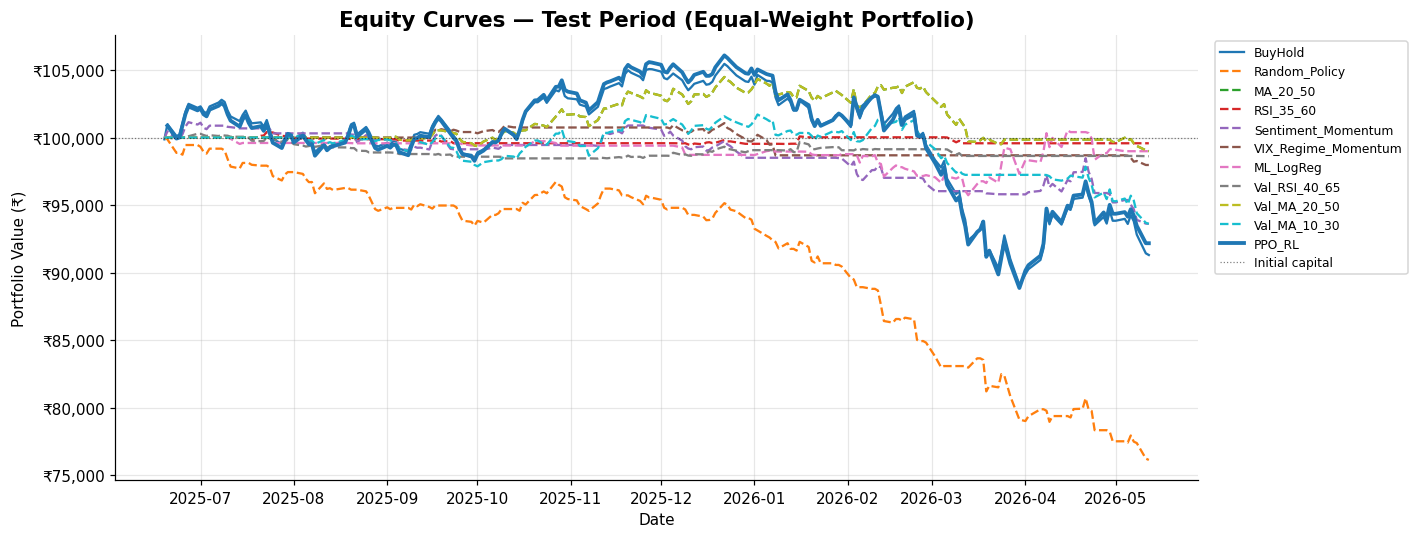

In [15]:
fig, ax = plt.subplots(figsize=(13,5))
for result in results:
    eq, name = result["equity"], result["strategy"]
    lw = 2.5 if "PPO" in name else 1.5
    ls = "-"  if "PPO" in name or name=="BuyHold" else "--"
    ax.plot(eq.index, eq.values, label=name, linewidth=lw, linestyle=ls)
ax.axhline(CFG.initial_cash, color="black", linewidth=0.8, linestyle=":", alpha=0.5, label="Initial capital")
ax.set_title("Equity Curves — Test Period (Equal-Weight Portfolio)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Portfolio Value (₹)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"₹{x:,.0f}"))
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


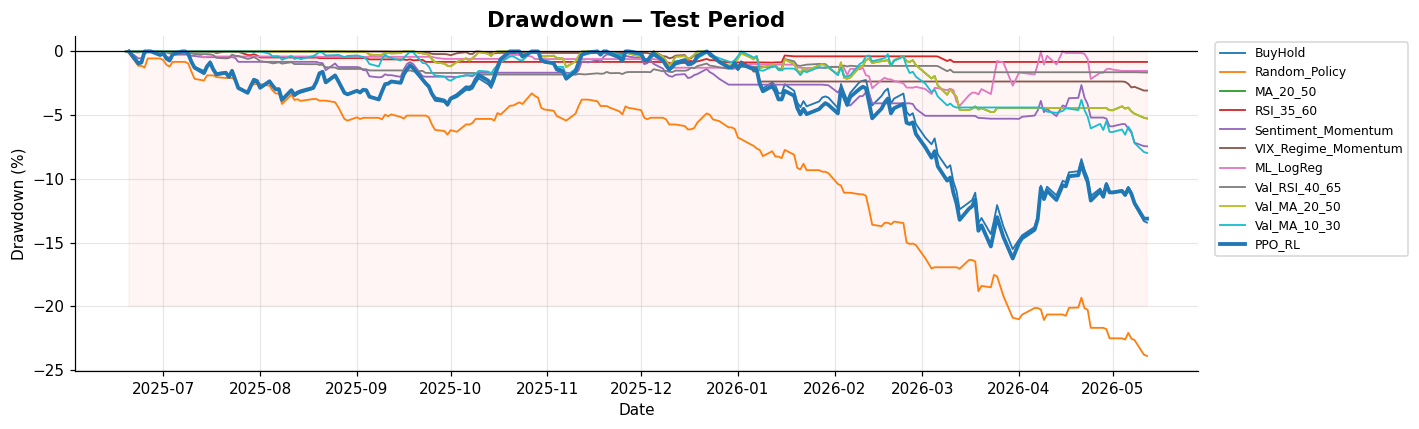

In [16]:
fig, ax = plt.subplots(figsize=(13,4))
for result in results:
    eq = result["equity"]; dd = eq/eq.cummax()-1
    lw = 2.5 if "PPO" in result["strategy"] else 1.2
    ax.plot(dd.index, dd.values*100, label=result["strategy"], linewidth=lw)
ax.fill_between(dd.index, 0, -20, alpha=0.04, color="red")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Drawdown — Test Period", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Drawdown (%)")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


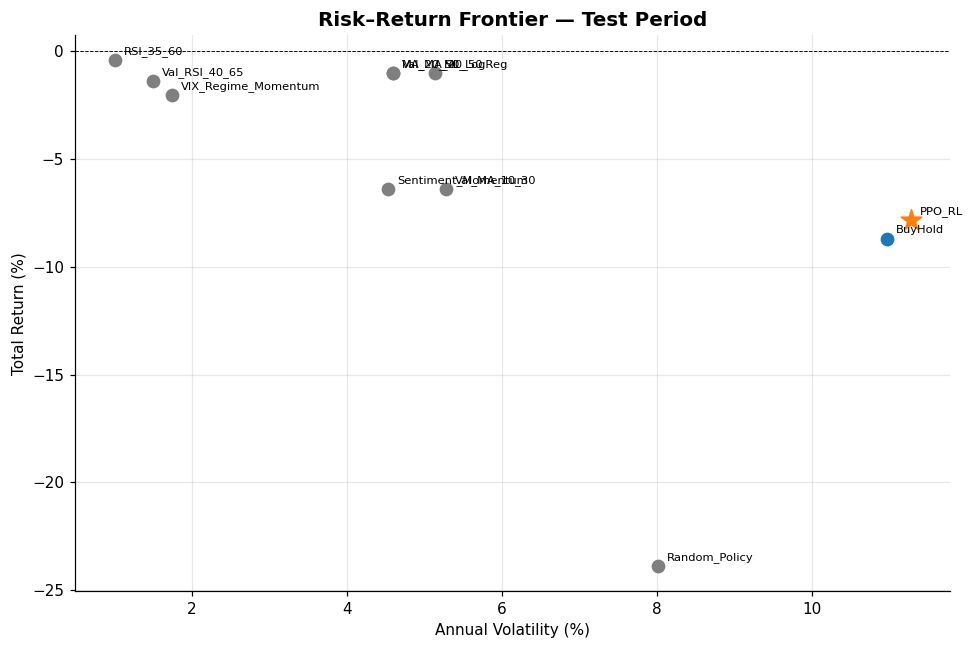

Stars = PPO  |  Blue = Buy & Hold  |  Gray = rule-based / ML


In [17]:
fig, ax = plt.subplots(figsize=(9,6))
for _, row in financial_metrics.iterrows():
    col  = "tab:orange" if "PPO" in row["strategy"] else ("tab:blue" if row["strategy"]=="BuyHold" else "tab:gray")
    mrkr = "*" if "PPO" in row["strategy"] else "o"
    ms   = 14 if "PPO" in row["strategy"] else 8
    ax.scatter(row["annual_volatility"]*100, row["total_return"]*100, c=col, marker=mrkr, s=ms**2, zorder=3)
    ax.annotate(row["strategy"], (row["annual_volatility"]*100, row["total_return"]*100),
                textcoords="offset points", xytext=(6,4), fontsize=7.5)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_xlabel("Annual Volatility (%)"); ax.set_ylabel("Total Return (%)")
ax.set_title("Risk–Return Frontier — Test Period", fontsize=13, fontweight="bold")
ax.grid(True,alpha=0.3); plt.tight_layout(); plt.show()
print("Stars = PPO  |  Blue = Buy & Hold  |  Gray = rule-based / ML")


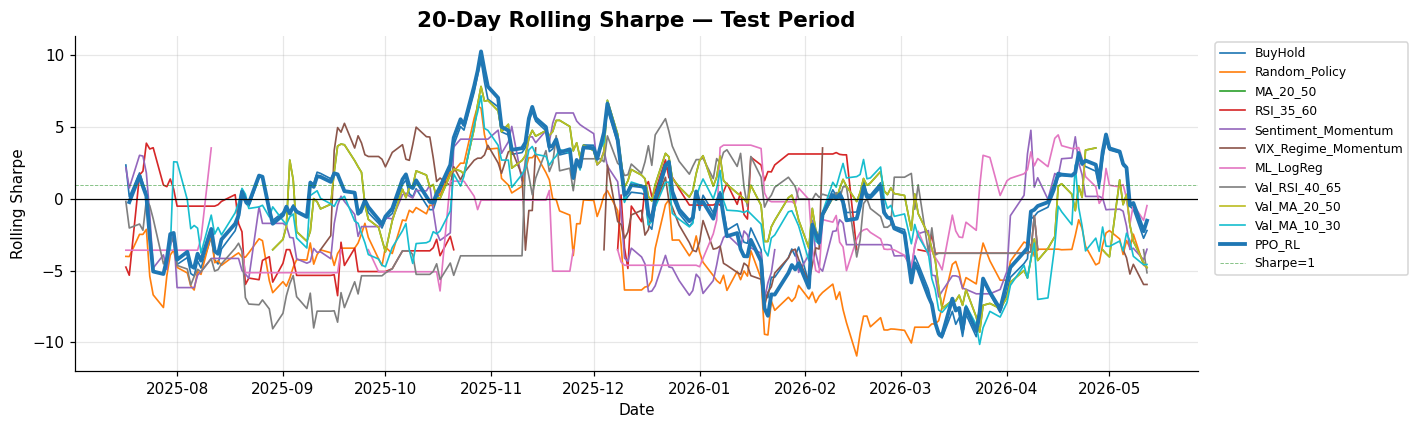

In [18]:
fig, ax = plt.subplots(figsize=(13,4))
for result in results:
    ret = result["equity"].pct_change().dropna()
    rs  = ret.rolling(20).mean() / ret.rolling(20).std() * np.sqrt(252)
    lw  = 2.5 if "PPO" in result["strategy"] else 1.1
    ax.plot(rs.index, rs.values, label=result["strategy"], linewidth=lw)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(1, color="green", linewidth=0.6, linestyle="--", alpha=0.5, label="Sharpe=1")
ax.set_title("20-Day Rolling Sharpe — Test Period", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Rolling Sharpe")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


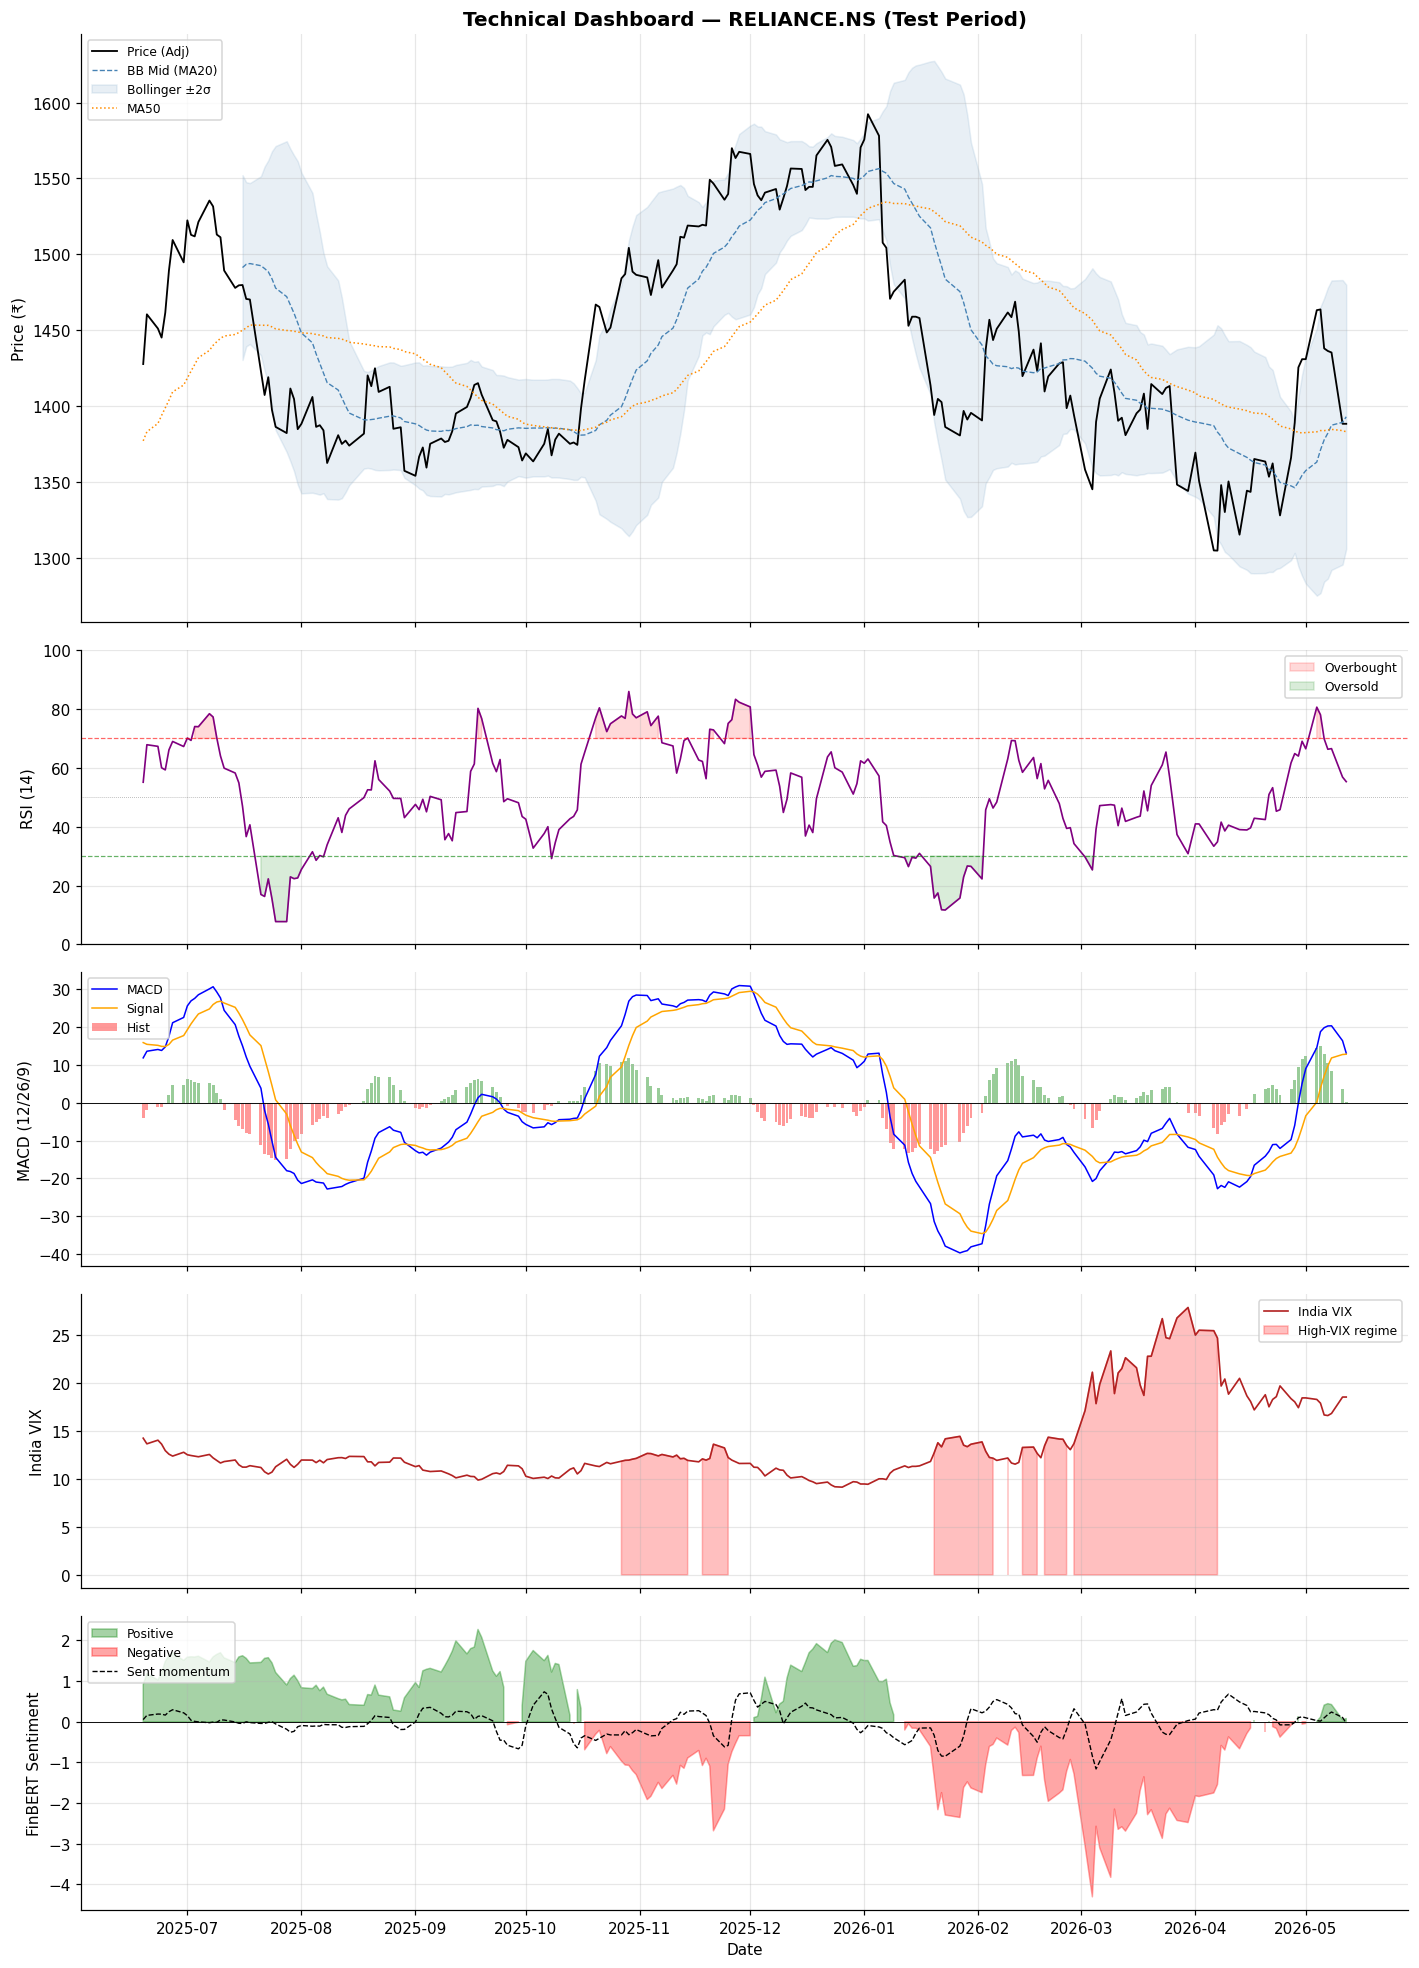

In [19]:
ref = CFG.tickers[0]
td  = test_df[test_df["ticker"]==ref].copy().reset_index(drop=True)
fig, axes = plt.subplots(5,1, figsize=(13,18), sharex=True,
                         gridspec_kw={"height_ratios":[3,1.5,1.5,1.5,1.5]})
ax = axes[0]
bm = td["price"].rolling(20).mean(); bs = td["price"].rolling(20).std()
ax.plot(td["Date"], td["price"],   color="black",      linewidth=1.2, label="Price (Adj)")
ax.plot(td["Date"], bm,            color="steelblue",  linewidth=0.9, linestyle="--", label="BB Mid (MA20)")
ax.fill_between(td["Date"], bm-2*bs, bm+2*bs, alpha=0.12, color="steelblue", label="Bollinger ±2σ")
ax.plot(td["Date"], td["ma50"],    color="darkorange", linewidth=1.0, linestyle=":", label="MA50")
ax.set_title(f"Technical Dashboard — {ref} (Test Period)", fontsize=13, fontweight="bold")
ax.set_ylabel("Price (₹)"); ax.legend(loc="upper left", fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[1]
ax.plot(td["Date"], td["rsi"], color="purple", linewidth=1.1)
ax.axhline(70, color="red",   linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline(30, color="green", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline(50, color="black", linewidth=0.5, linestyle=":", alpha=0.4)
ax.fill_between(td["Date"], td["rsi"], 70, where=td["rsi"]>=70, alpha=0.15, color="red",   label="Overbought")
ax.fill_between(td["Date"], td["rsi"], 30, where=td["rsi"]<=30, alpha=0.15, color="green", label="Oversold")
ax.set_ylabel("RSI (14)"); ax.set_ylim(0,100); ax.legend(loc="upper right", fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[2]
ax.plot(td["Date"], td["macd"],        color="blue",   linewidth=1.0, label="MACD")
ax.plot(td["Date"], td["macd_signal"], color="orange", linewidth=1.0, label="Signal")
ax.bar(td["Date"],  td["macd_hist"],   color=np.where(td["macd_hist"]>=0,"green","red"), alpha=0.4, label="Hist")
ax.axhline(0, color="black", linewidth=0.6); ax.set_ylabel("MACD (12/26/9)")
ax.legend(loc="upper left", fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[3]
ax.plot(td["Date"], td["india_vix"], color="firebrick", linewidth=1.1, label="India VIX")
ax.fill_between(td["Date"], td["india_vix"], where=td["high_vix_regime"]==1,
                alpha=0.25, color="red", label="High-VIX regime")
ax.set_ylabel("India VIX"); ax.legend(loc="upper right", fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[4]
ax.fill_between(td["Date"], td["sentiment"], 0,
                where=td["sentiment"]>=0, alpha=0.35, color="green", label="Positive")
ax.fill_between(td["Date"], td["sentiment"], 0,
                where=td["sentiment"]<0,  alpha=0.35, color="red",   label="Negative")
ax.plot(td["Date"], td["sent_momentum"], color="black", linewidth=0.9, linestyle="--", label="Sent momentum")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("FinBERT Sentiment"); ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=8); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


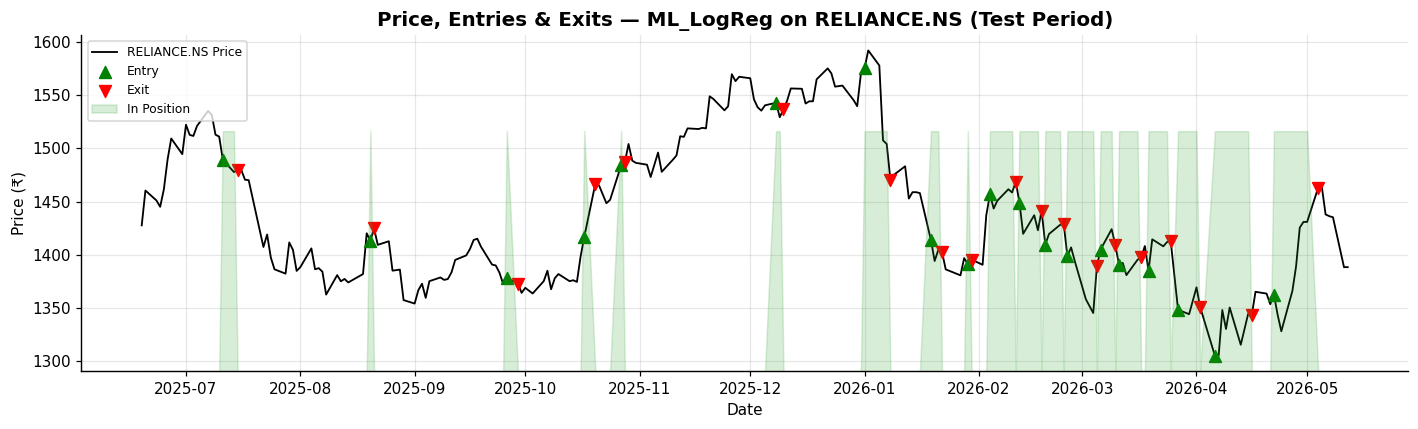

In [20]:
best_name   = financial_metrics.iloc[0]["strategy"]
best_result = next(r for r in results if r["strategy"]==best_name)
ref = CFG.tickers[0]
td  = test_df[test_df["ticker"]==ref].copy()
price = td.groupby(pd.to_datetime(td["Date"]))["price"].last()
pos   = best_result["positions"].groupby(level=0).last()
pos   = (pos > 0).astype(int)
cidx  = price.index.intersection(pos.index)
price, pos = price.reindex(cidx), pos.reindex(cidx).fillna(0)
entries = cidx[(pos.values==1) & (np.concatenate([[0],pos.values[:-1]])==0)]
exits   = cidx[(pos.values==0) & (np.concatenate([[0],pos.values[:-1]])==1)]
fig, ax1 = plt.subplots(figsize=(13,4))
ax1.plot(price.index, price.values, color="black", linewidth=1.2, label=f"{ref} Price")
ax2 = ax1.twinx()
ax2.fill_between(pos.index, 0, pos.values, alpha=0.18, color="tab:green", label="In Position")
ax2.set_ylim(0,1.4); ax2.set_yticks([])
ax1.scatter(entries, price.reindex(entries), marker="^", color="green", zorder=5, s=60, label="Entry")
ax1.scatter(exits,   price.reindex(exits),   marker="v", color="red",   zorder=5, s=60, label="Exit")
ax1.set_title(f"Price, Entries & Exits — {best_name} on {ref} (Test Period)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Date"); ax1.set_ylabel("Price (₹)")
lines1,l1 = ax1.get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc="upper left", fontsize=8); ax1.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


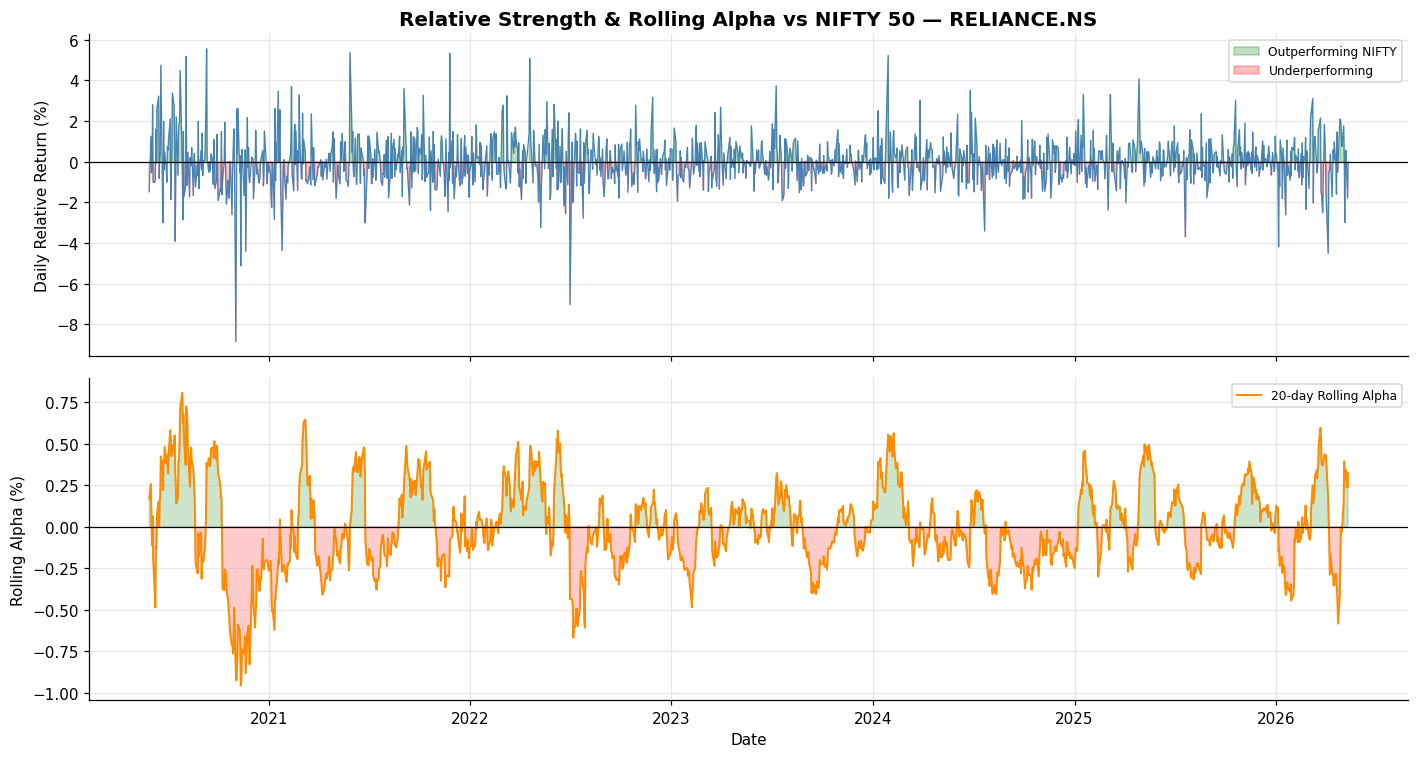

In [21]:
ref = CFG.tickers[0]; pd_ = data[data["ticker"]==ref].copy()
fig, (ax1,ax2) = plt.subplots(2,1, figsize=(13,7), sharex=True)
ax1.plot(pd_["Date"], pd_["relative_strength"]*100, linewidth=0.8, color="steelblue")
ax1.fill_between(pd_["Date"], pd_["relative_strength"]*100, 0,
                 where=pd_["relative_strength"]>=0, alpha=0.25, color="green", label="Outperforming NIFTY")
ax1.fill_between(pd_["Date"], pd_["relative_strength"]*100, 0,
                 where=pd_["relative_strength"]<0,  alpha=0.25, color="red",   label="Underperforming")
ax1.axhline(0, color="black", linewidth=0.8); ax1.set_ylabel("Daily Relative Return (%)")
ax1.set_title(f"Relative Strength & Rolling Alpha vs NIFTY 50 — {ref}", fontsize=13, fontweight="bold")
ax1.legend(fontsize=8); ax1.grid(True,alpha=0.3)
ax2.plot(pd_["Date"], pd_["rolling_alpha"]*100, color="darkorange", linewidth=1.3, label="20-day Rolling Alpha")
ax2.fill_between(pd_["Date"], pd_["rolling_alpha"]*100, 0,
                 where=pd_["rolling_alpha"]>=0, alpha=0.2, color="green")
ax2.fill_between(pd_["Date"], pd_["rolling_alpha"]*100, 0,
                 where=pd_["rolling_alpha"]<0,  alpha=0.2, color="red")
ax2.axhline(0, color="black", linewidth=0.8); ax2.set_ylabel("Rolling Alpha (%)")
ax2.set_xlabel("Date"); ax2.legend(fontsize=8); ax2.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


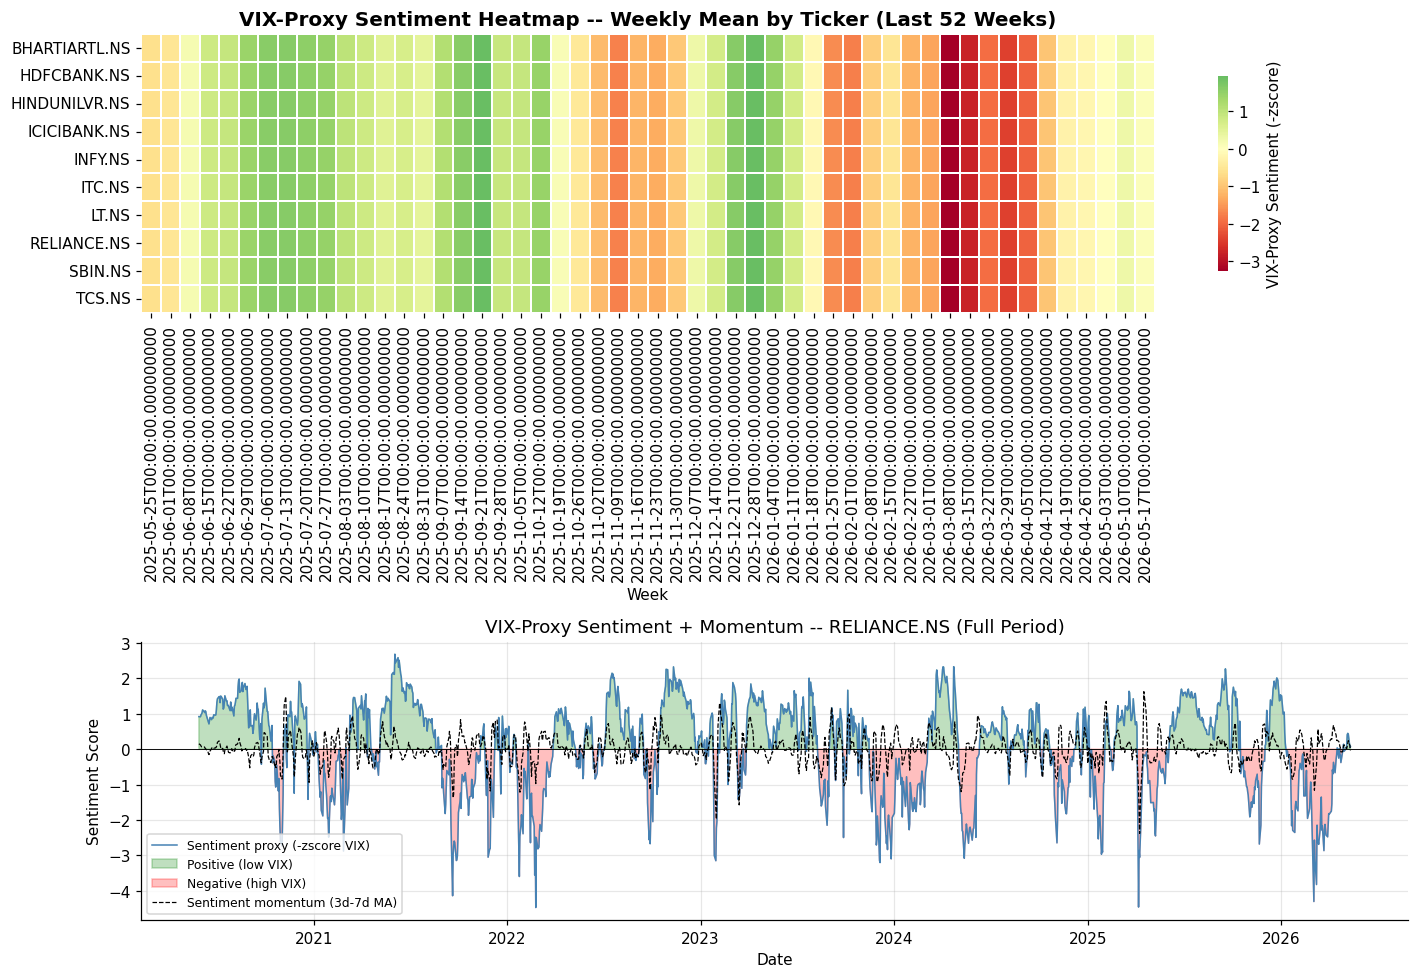

Average VIX-proxy sentiment by ticker (higher = lower-fear environment):
  BHARTIARTL.NS        +0.075  X
  HDFCBANK.NS          +0.075  X
  HINDUNILVR.NS        +0.075  X
  ICICIBANK.NS         +0.075  X
  INFY.NS              +0.075  X
  ITC.NS               +0.075  X
  LT.NS                +0.075  X
  RELIANCE.NS          +0.075  X
  SBIN.NS              +0.075  X
  TCS.NS               +0.075  X


In [22]:
# Sentiment proxy heatmap: -zscore(VIX, 60d) -- now has real signal across full period
sent_pivot = data.pivot_table(index="Date",columns="ticker",values="sentiment",aggfunc="mean")
sent_pivot_w = sent_pivot.resample("W").mean().iloc[-52:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

sns.heatmap(sent_pivot_w.T, cmap="RdYlGn", center=0, linewidths=0.3,
            ax=ax1, cbar_kws={"label":"VIX-Proxy Sentiment (-zscore)","shrink":0.7})
ax1.set_title("VIX-Proxy Sentiment Heatmap -- Weekly Mean by Ticker (Last 52 Weeks)",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Week"); ax1.set_ylabel("")

ref = CFG.tickers[0]
td  = data[data["ticker"]==ref].copy()
ax2.plot(td["Date"], td["sentiment"], color="steelblue", linewidth=1.0,
         label="Sentiment proxy (-zscore VIX)")
ax2.fill_between(td["Date"], td["sentiment"], 0,
                 where=td["sentiment"]>=0, alpha=0.25, color="green", label="Positive (low VIX)")
ax2.fill_between(td["Date"], td["sentiment"], 0,
                 where=td["sentiment"]<0,  alpha=0.25, color="red",   label="Negative (high VIX)")
ax2.plot(td["Date"], td["sent_momentum"], color="black", linewidth=0.8,
         linestyle="--", label="Sentiment momentum (3d-7d MA)")
ax2.axhline(0, color="black", linewidth=0.6)
ax2.set_title(f"VIX-Proxy Sentiment + Momentum -- {ref} (Full Period)", fontsize=12)
ax2.set_ylabel("Sentiment Score"); ax2.set_xlabel("Date")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

sent_mean = data.groupby("ticker")["sentiment"].mean().sort_values(ascending=False)
print("Average VIX-proxy sentiment by ticker (higher = lower-fear environment):")
for t,v in sent_mean.items():
    bar = "X"*max(int(abs(v)*10),1)
    print(f"  {t:20s} {'+' if v>=0 else ''}{v:.3f}  {bar}")


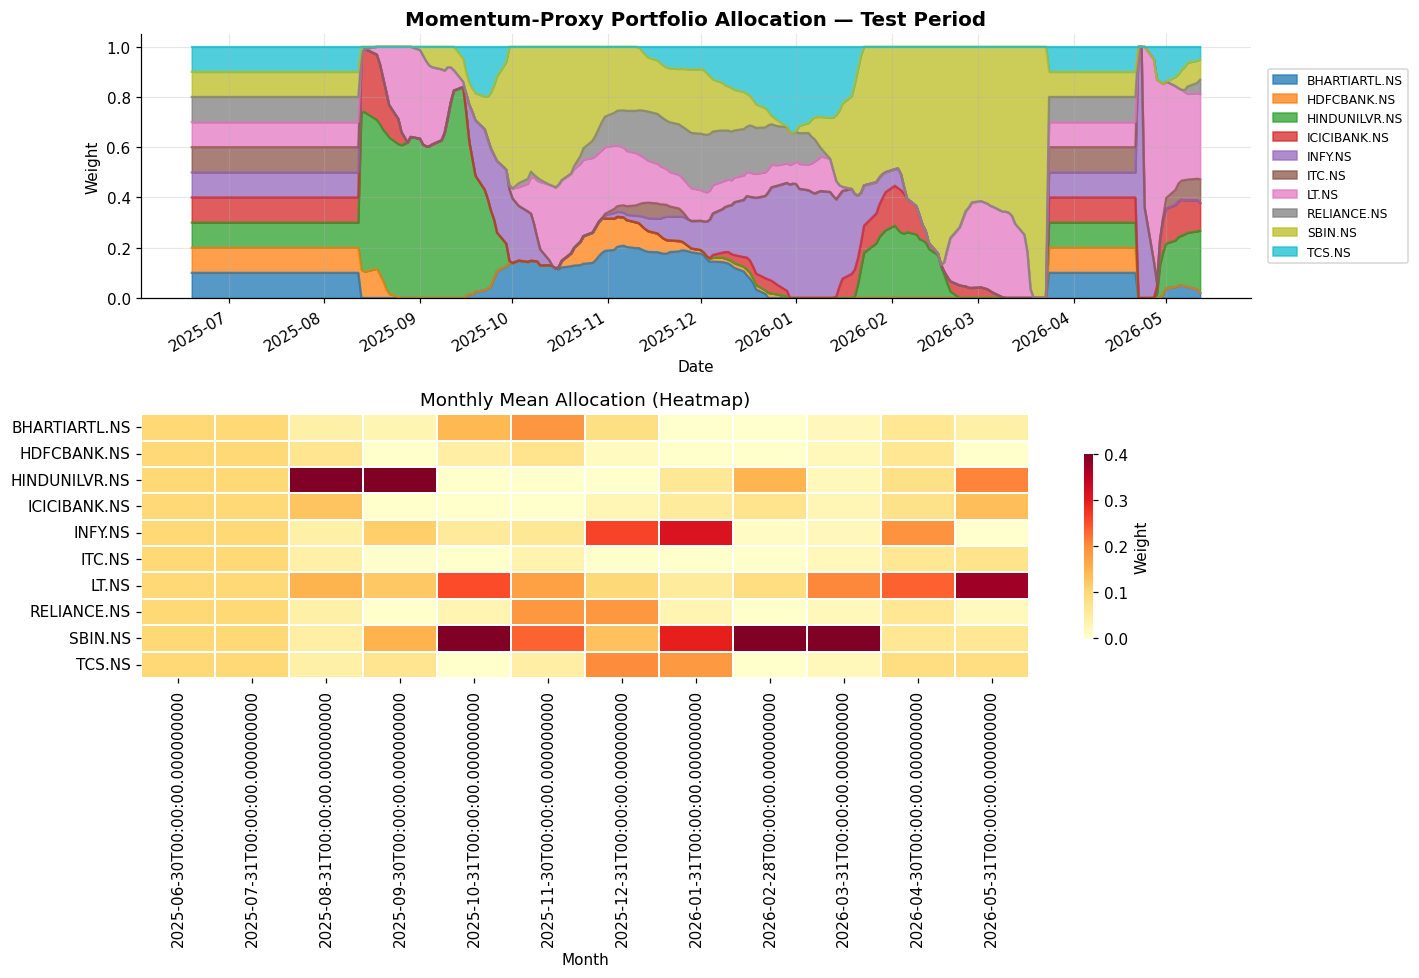

In [24]:
pivot = test_df.pivot_table(index="Date",columns="ticker",values="price",aggfunc="last").ffill()
w     = pivot.pct_change(20).rolling(20).mean().fillna(0).clip(lower=0)
rs    = w.sum(axis=1).replace(0, np.nan)
w     = w.div(rs, axis=0).fillna(1/w.shape[1])
fig, (ax1,ax2) = plt.subplots(2,1, figsize=(13,9))
w.plot.area(ax=ax1, alpha=0.75)
ax1.set_title("Momentum-Proxy Portfolio Allocation — Test Period", fontsize=13, fontweight="bold")
ax1.set_ylabel("Weight"); ax1.set_xlabel("Date")
ax1.legend(loc="center left", bbox_to_anchor=(1.01,0.5), fontsize=8); ax1.grid(True,alpha=0.3)
sns.heatmap(w.resample("M").mean().T, cmap="YlOrRd", ax=ax2,
            linewidths=0.3, cbar_kws={"label":"Weight","shrink":0.7}, vmin=0, vmax=0.4)
ax2.set_title("Monthly Mean Allocation (Heatmap)", fontsize=12)
ax2.set_xlabel("Month"); ax2.set_ylabel("")
plt.tight_layout(); plt.show()


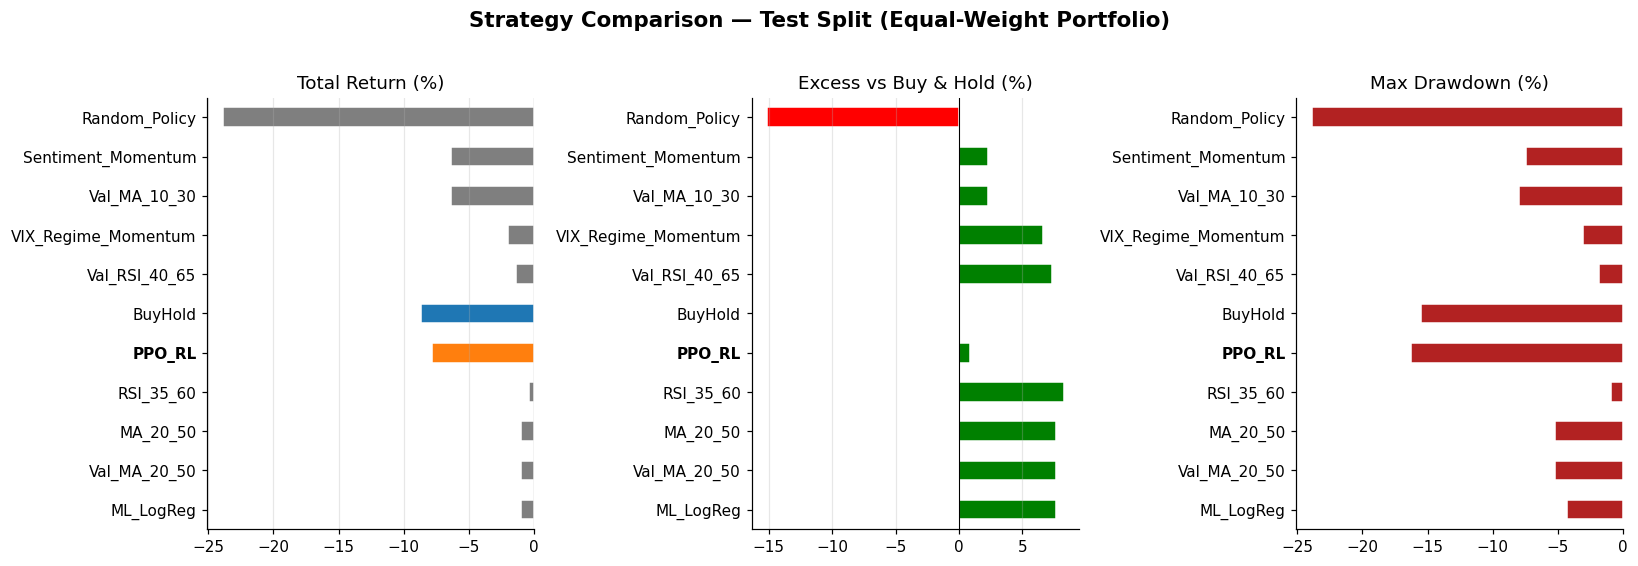

In [23]:
plot_m = financial_metrics.set_index("strategy")[["total_return","benchmark_excess_return","max_drawdown"]].copy()*100
fig, axes = plt.subplots(1,3, figsize=(15,5))
colors_tr = ["tab:orange" if "PPO" in n else "tab:blue" if n=="BuyHold" else "tab:gray" for n in plot_m.index]
plot_m["total_return"].plot.barh(ax=axes[0], color=colors_tr, edgecolor="white")
axes[0].set_title("Total Return (%)"); axes[0].axvline(0,color="black",lw=0.7); axes[0].grid(True,axis="x",alpha=0.3)
plot_m["benchmark_excess_return"].plot.barh(ax=axes[1],
    color=["green" if v>=0 else "red" for v in plot_m["benchmark_excess_return"]], edgecolor="white")
axes[1].set_title("Excess vs Buy & Hold (%)"); axes[1].axvline(0,color="black",lw=0.7); axes[1].grid(True,axis="x",alpha=0.3)
plot_m["max_drawdown"].plot.barh(ax=axes[2], color="firebrick", edgecolor="white")
axes[2].set_title("Max Drawdown (%)")
for ax in axes:
    ax.set_ylabel("")
    for lbl in ax.get_yticklabels():
        if "PPO" in lbl.get_text(): lbl.set_fontweight("bold")
plt.suptitle("Strategy Comparison — Test Split (Equal-Weight Portfolio)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


## 13 · Walk-Forward Backtesting — Rule-Based Strategies

Windows sliced by **unique trading dates** so each training window contains the same calendar span for all 10 tickers. Each test window is backtested via the same multi-stock portfolio engine.


Walk-Forward Summary:
          strategy  windows  avg_return  avg_excess  avg_sharpe  avg_max_dd  pct_positive
           BuyHold        8    0.051584    0.000000    1.023427   -0.073908         0.750
       Breakout_20        8    0.008530   -0.043054    0.077913   -0.038199         0.625
          MA_20_50        8   -0.003541   -0.055125   -0.312387   -0.036035         0.500
  MomentumPullback        8   -0.003620   -0.055204   -0.356437   -0.025364         0.375
    VIX_Regime_Mom        8   -0.003994   -0.055578   -0.707325   -0.016647         0.375
Sentiment_Momentum        8   -0.006612   -0.058196   -0.269096   -0.041396         0.375
         ML_LogReg        8   -0.013469   -0.065053   -0.426982   -0.040414         0.375


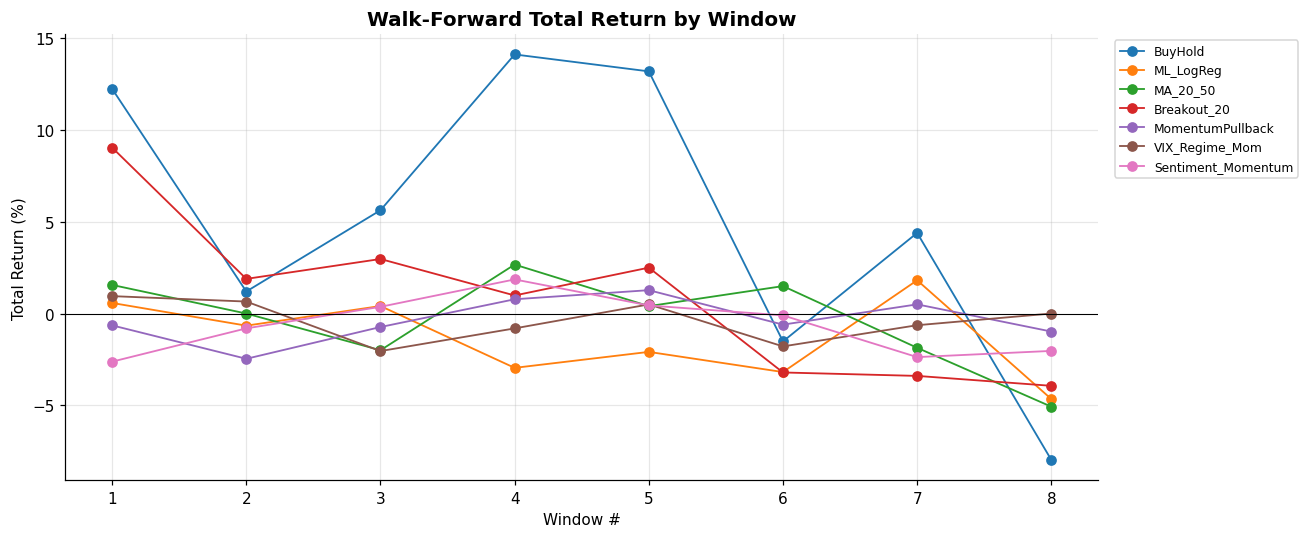

In [25]:
def walk_forward_backtest(full_df, train_days=500, test_days=120, step_days=120):
    dates  = sorted(full_df["Date"].unique())
    rows, s, w = [], 0, 1
    while s + train_days + test_days <= len(dates):
        td_set = set(dates[s:s+train_days]); te_set = set(dates[s+train_days:s+train_days+test_days])
        wf_tr  = full_df[full_df["Date"].isin(td_set)].reset_index(drop=True)
        wf_te  = full_df[full_df["Date"].isin(te_set)].reset_index(drop=True)
        cands = {
            "BuyHold":            {"kind":"BuyHold"},
            "ML_LogReg":          {"kind":"logreg"},
            "MA_20_50":           {"kind":"ma","short":20,"long":50,"vix_limit":None},
            "Breakout_20":        {"kind":"breakout","lookback":20,"exit_lookback":10,"vix_limit":None},
            "MomentumPullback":   {"kind":"momentum_pullback","rsi_max":55},
            "VIX_Regime_Mom":     {"kind":"vix_regime_momentum"},
            "Sentiment_Momentum": {"kind":"sentiment_momentum"},
        }
        wf_res = [run_portfolio_backtest(wf_te, p, n, logreg_train_df=wf_tr) for n,p in cands.items()]
        wf_bm  = next(r for r in wf_res if r["strategy"]=="BuyHold")
        for res in wf_res:
            row = performance_metrics(res, wf_bm, wf_te)
            row.update({"window":w,"test_start":wf_te["Date"].min(),"test_end":wf_te["Date"].max()})
            rows.append(row)
        s += step_days; w += 1
    return pd.DataFrame(rows)

walk_forward_metrics = walk_forward_backtest(data)
wf_summary = (walk_forward_metrics
    .groupby("strategy", as_index=False)
    .agg(windows=("window","nunique"), avg_return=("total_return","mean"),
         avg_excess=("benchmark_excess_return","mean"), avg_sharpe=("Sharpe","mean"),
         avg_max_dd=("max_drawdown","mean"),
         pct_positive=("total_return", lambda x:(x>0).mean()))
    .sort_values(["avg_excess","avg_sharpe"], ascending=False))
print("Walk-Forward Summary:"); print(wf_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(12,5))
for strat in walk_forward_metrics["strategy"].unique():
    sub = walk_forward_metrics[walk_forward_metrics["strategy"]==strat]
    ax.plot(sub["window"].values, sub["total_return"].values*100, marker="o", label=strat, linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Walk-Forward Total Return by Window", fontsize=13, fontweight="bold")
ax.set_xlabel("Window #"); ax.set_ylabel("Total Return (%)")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()


## 14 · Risk-Management Sensitivity Analysis

4×4 SL/TP grid on the best non-trivial strategy. Robustness = Sharpe stable across the grid.

Risk sensitivity: MA_20_50 (equal-weight portfolio)
 stop_loss  take_profit  total_return  benchmark_excess_return    Sharpe  max_drawdown  trades  win_rate
      0.04         0.08     -0.010989                 0.076021 -0.256997     -0.054682      41  0.292683
      0.04         0.12     -0.010045                 0.076964 -0.234291     -0.053282      40  0.275000
      0.04         0.16     -0.012546                 0.074464 -0.297157     -0.055727      33  0.272727
      0.04         0.20     -0.008364                 0.078646 -0.194078     -0.050529      33  0.272727
      0.06         0.08     -0.011085                 0.075924 -0.253436     -0.054473      37  0.297297
      0.06         0.12     -0.010080                 0.076930 -0.228294     -0.052599      33  0.303030
      0.06         0.16     -0.011452                 0.075558 -0.262708     -0.055235      29  0.310345
      0.06         0.20     -0.015420                 0.071590 -0.364399     -0.057838      30  0.300000
   

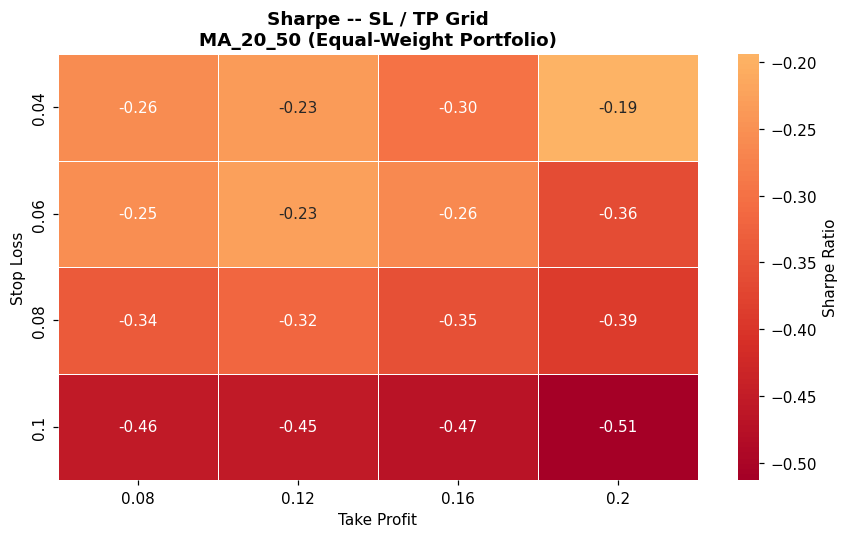

In [26]:
# Run risk sensitivity on MA_20_50 -- trades frequently so SL/TP thresholds
# actually fire, producing a meaningful non-degenerate grid.
# Previous run used Val_RSI_30_55 which made only 6 trades -- identical grid across all 16 cells.
base_name   = "MA_20_50"
base_params = FIXED_STRATS["MA_20_50"]

risk_rows = []
for sl in [0.04, 0.06, 0.08, 0.10]:
    for tp in [0.08, 0.12, 0.16, 0.20]:
        res = run_portfolio_backtest(test_df, base_params, f"{base_name}_SL{sl:.0%}_TP{tp:.0%}",
                                     stop_loss=sl, take_profit=tp)
        row = performance_metrics(res, benchmark_result, test_df)
        row.update({"stop_loss":sl,"take_profit":tp}); risk_rows.append(row)

risk_df = pd.DataFrame(risk_rows)
print(f"Risk sensitivity: {base_name} (equal-weight portfolio)")
print(risk_df[["stop_loss","take_profit","total_return","benchmark_excess_return",
               "Sharpe","max_drawdown","trades","win_rate"]].to_string(index=False))

sharpe_pivot = risk_df.pivot(index="stop_loss", columns="take_profit", values="Sharpe")
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(sharpe_pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label":"Sharpe Ratio"})
ax.set_title(f"Sharpe -- SL / TP Grid\n{base_name} (Equal-Weight Portfolio)", fontsize=12, fontweight="bold")
ax.set_xlabel("Take Profit"); ax.set_ylabel("Stop Loss")
plt.tight_layout(); plt.show()


## 15 · Summary & Export

In [27]:
fm   = financial_metrics.sort_values("Sharpe", ascending=False).reset_index(drop=True)
best = fm.iloc[0]
bh   = fm[fm["strategy"]=="BuyHold"].iloc[0]
ppo  = fm[fm["strategy"]=="PPO_RL"].iloc[0] if "PPO_RL" in fm["strategy"].values else None

print("  PORTFOLIO OPTIMIZATION — RESULTS SUMMARY (TEST SPLIT)")
print(f"  Universe   : {len(CFG.tickers)} NIFTY 50 stocks")
print(f"  Backtest   : Equal-weight portfolio, ₹{CFG.initial_cash/len(CFG.tickers):,.0f}/ticker")
print(f"  Costs      : TC={CFG.transaction_cost:.1%}  Slippage={CFG.slippage:.2%}")
print("-" * 65)

print(f"{'Strategy':30s} {'Return':>8} {'Excess':>8} {'Sharpe':>7} {'MaxDD':>8}")
print("-" * 65)
for _, row in fm.iterrows():
    tag = " ◄ PPO" if "PPO" in row["strategy"] else (" ◄ BH" if row["strategy"]=="BuyHold" else "")
    print(f"{row['strategy']:30s} {row['total_return']:>7.2%} {row['benchmark_excess_return']:>7.2%} "
          f"{row['Sharpe']:>6.2f}  {row['max_drawdown']:>7.2%}  {tag}")
print(f"\nBest risk-adjusted  : {best['strategy']}")
print(f"  Return / Excess    : {best['total_return']:.2%} / {best['benchmark_excess_return']:.2%}")
print(f"  Sharpe / Sortino   : {best['Sharpe']:.2f} / {best.get('Sortino', float('nan')):.2f}")
print(f"  Max drawdown       : {best['max_drawdown']:.2%}")
print(f"  Signal accuracy    : {best['signal_accuracy']:.2%}")
if ppo is not None:
    print(f"\nPPO RL agent:")
    print(f"  Return / Excess    : {ppo['total_return']:.2%} / {ppo['benchmark_excess_return']:.2%}")
    print(f"  Sharpe             : {ppo['Sharpe']:.2f}")
    print(f"  Max drawdown       : {ppo['max_drawdown']:.2%}")
print(f"\nPassive Buy & Hold   : {bh['total_return']:.2%}")


  PORTFOLIO OPTIMIZATION — RESULTS SUMMARY (TEST SPLIT)
  Universe   : 10 NIFTY 50 stocks
  Backtest   : Equal-weight portfolio, ₹10,000/ticker
  Costs      : TC=0.1%  Slippage=0.05%
-----------------------------------------------------------------
Strategy                         Return   Excess  Sharpe    MaxDD
-----------------------------------------------------------------
ML_LogReg                       -1.01%   7.69%  -0.20   -4.27%  
Val_MA_20_50                    -1.01%   7.69%  -0.23   -5.26%  
MA_20_50                        -1.01%   7.69%  -0.23   -5.26%  
RSI_35_60                       -0.42%   8.28%  -0.48   -0.97%  
PPO_RL                          -7.83%   0.87%  -0.86  -16.24%   ◄ PPO
BuyHold                         -8.70%   0.00%  -0.88  -15.51%   ◄ BH
Val_RSI_40_65                   -1.39%   7.31%  -1.06   -1.83%  
VIX_Regime_Momentum             -2.03%   6.67%  -1.33   -3.07%  
Val_MA_10_30                    -6.40%   2.31%  -1.40   -7.97%  
Sentiment_Momentum     

In [28]:
Path("results").mkdir(exist_ok=True)
financial_metrics.to_csv("results/financial_metrics.csv", index=False)
walk_forward_metrics.to_csv("results/walk_forward_metrics.csv", index=False)
risk_df.to_csv("results/risk_sensitivity.csv", index=False)
for res in results:
    sname = res["strategy"].replace(" ","_")
    if not res["trades"].empty:
        res["trades"].to_csv(f"results/trades_{sname}.csv", index=False)
if not ppo_ablation_table.empty:
    ppo_ablation_table.to_csv("results/ppo_ablation.csv", index=False)
print(f"Exported {len(list(Path('results').glob('*.csv')))} CSV files to results/")


Exported 14 CSV files to results/
